In [1]:
import numpy as np
from sklearn.decomposition import PCA

In [2]:
filename = 'quant.csv'
dense_coding_table = []
for line in open(filename):
    dense_coding_table.append(line.strip('\n').split(','))
for x in dense_coding_table[:10]:
    print(x)

['relation', 'eng_in', 'eng_on', 'eng_at', 'cyn_yn', 'cym_ar', 'cym_mewn', 'cym_zero', 'cym_wrth', 'cym_other', 'deu_in', 'deu_auf', 'deu_zu', 'deu_an', 'deu_nach', 'deu_zero', 'deu_other', 'pol_w', 'pol_na', 'pol_z', 'pol_u', 'pol_przy', 'pol_podczas', 'pol_zaś', 'pol_zero', 'pol_other']
['c-lff', '15', '0', '0', '11', '0', '1', '1', '0', '0', '10', '4', '0', '0', '0', '0', '0', '8', '5', '0', '0', '0', '0', '0', '0', '0']
['c-lfp', '1', '0', '0', '1', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0', '0', '0', '0', '0']
['c-tfp', '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0', '0', '0', '0']
['c-loc', '9', '0', '0', '8', '0', '1', '0', '0', '0', '8', '0', '0', '1', '0', '0', '0', '7', '2', '0', '0', '0', '0', '0', '0', '0']
['s-grav', '0', '8', '0', '0', '8', '0', '0', '0', '0', '0', '7', '0', '0', '0', '0', '0', '0', '6', '0', '0', '0', '0', '0', '0', '0']
['s-hang', '0', '2', '0', '0', 

In [3]:
#def get_sparse_coding(dense_coding_table, no_response):
#    languages = dense_coding_table[0][1:]
#    sparse_dict = { language : {} for language in languages }
#    sparse_coding_table = []
#    for i,language in enumerate(languages, start=1):
#        for row in dense_coding_table[1:]:
#            for morpheme in row[i].split(' '):
#                if morpheme == no_response: continue
#                elif morpheme not in sparse_dict[language]: 
#                    sparse_dict[language][morpheme] = len(sparse_dict[language])
#    header = [language + '_' + morpheme for language in languages 
#              for morpheme in sorted(sparse_dict[language], key = lambda k : sparse_dict[language][k])]
#    for row in dense_coding_table[1:]:
#        sparse_row = []
#        for i,language in enumerate(languages, start=1):
#            sparse_row_i = [0 for j in range(len(sparse_dict[language]))]
#            for morpheme in row[i].split(' '):
#                if morpheme == no_response: continue
#                else:
#                    index = sparse_dict[language][morpheme]
#                    sparse_row_i[index] = 1
#            sparse_row.extend(sparse_row_i)
#        sparse_coding_table.append(sparse_row)
#    return header, sparse_coding_table, sparse_dict
            

#header, sparse_coding_table, sparse_dict = get_sparse_coding(dense_coding_table, no_response = '--')
#print('>>> sparse dict', sparse_dict)
#print('>>> header', header)
#for i in sparse_coding_table[:10]:
#    print(i)

>>> sparse dict {'eng': {'in': 0, 'on': 1, 'at': 2, 'by': 3}, 'cym': {'yn': 0, 'ar': 1, 'zero': 2, 'mewn': 3, 'wrth': 4}, 'deu': {'in': 0, 'auf': 1, 'zur': 2, 'vor': 3, 'an': 4}, 'fin': {'-ssa': 0, '-lla': 1, '-lle': 2, 'zero': 3}, 'hat': {'nan': 0, 'sou': 1, 'zero': 2, 'bò_la': 3}, 'hau': {'cikin': 0, 'a': 1, 'kan': 2, 'ciki': 3, 'zero': 4}, 'hin': {'mẽ': 0, 'par': 1, 'zero': 2, 'ke': 3, 'pas': 4, 'kinare': 5}, 'jav': {'ing': 0, 'sacedhaké': 1, 'sacedhaking': 2, 'pinggir': 3, 'sajroning': 4, 'sakiwa': 5, 'tengené': 6}, 'pol': {'w': 0, 'na': 1, 'z': 2, 'u': 3, 'przy': 4}, 'tur': {'-inda': 0, '-da': 1}, 'yor': {'ninu': 0, 'li': 1, 'ni': 2, 'lori': 3, 'lẹhin': 4, 'sinu': 5, 'leti': 6}}
>>> header ['eng_in', 'eng_on', 'eng_at', 'eng_by', 'cym_yn', 'cym_ar', 'cym_zero', 'cym_mewn', 'cym_wrth', 'deu_in', 'deu_auf', 'deu_zur', 'deu_vor', 'deu_an', 'fin_-ssa', 'fin_-lla', 'fin_-lle', 'fin_zero', 'hat_nan', 'hat_sou', 'hat_zero', 'hat_bò_la', 'hau_cikin', 'hau_a', 'hau_kan', 'hau_ciki', 'hau_z

In [5]:
P = PCA()
coordinates = P.fit_transform(dense_coding_table)
print(P.explained_variance_ratio_)

ValueError: could not convert string to float: 'relation'

-1.3115719657780487 -0.25934974777259157 c-lff
-0.074311469394992 1.3935990587028269 c-lff
-1.5488200540065291 -0.39228941268514994 c-loc
1.8945094639190503 -1.187442509169562 s-hang
-1.2970592167272461 0.26874230155536694 c-loc
-1.0819964061559095 -0.6688375372137549 c-lfp
1.2473201032452461 -0.4321965950341666 s-grav
-0.4875988195563762 -0.4258462225566944 c-lff
-0.23320419753095922 0.1090309700112268 a-cl
2.066522571050568 -0.26603593850399876 s-grav
-0.034097899926858 1.3948845138512054 c-lff
0.3764390853307096 0.6219226127854204 a-cl
-1.2854034240789094 -0.52277292633155 c-lff
-1.1066357859596325 0.3596849698022184 c-lff
1.8945094639190503 -1.1874425091695622 s-hang
-1.3071433632724085 0.4675583188911007 c-loc
0.14483485870404922 0.7845143292665959 c-lff
0.9286416869988183 0.04421709776170166 a-cl
-0.034097899926857994 1.3948845138512054 c-lff
2.026309001582433 -0.2673213936523765 s-grav
1.371310103475251 0.35806605015462767 c-tfp
-1.3294736646027903 -0.3499552333376322 c-loc
0.19

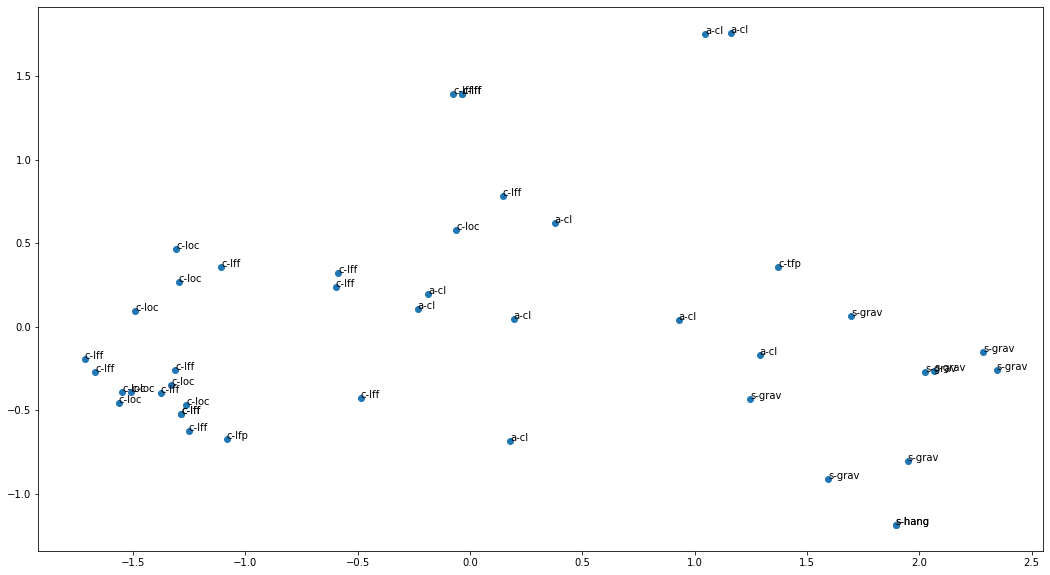

0 eng_in


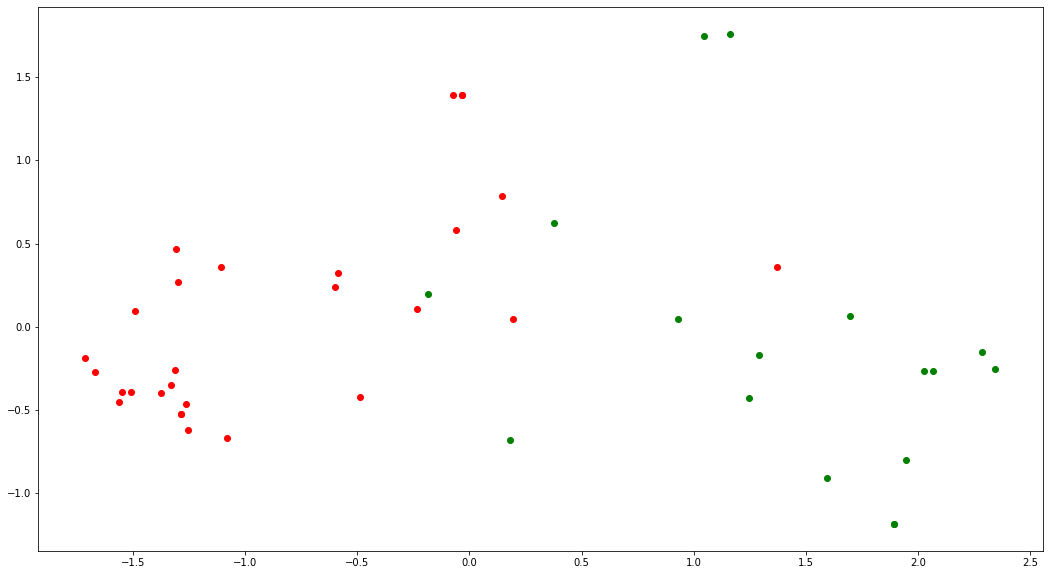

1 eng_on


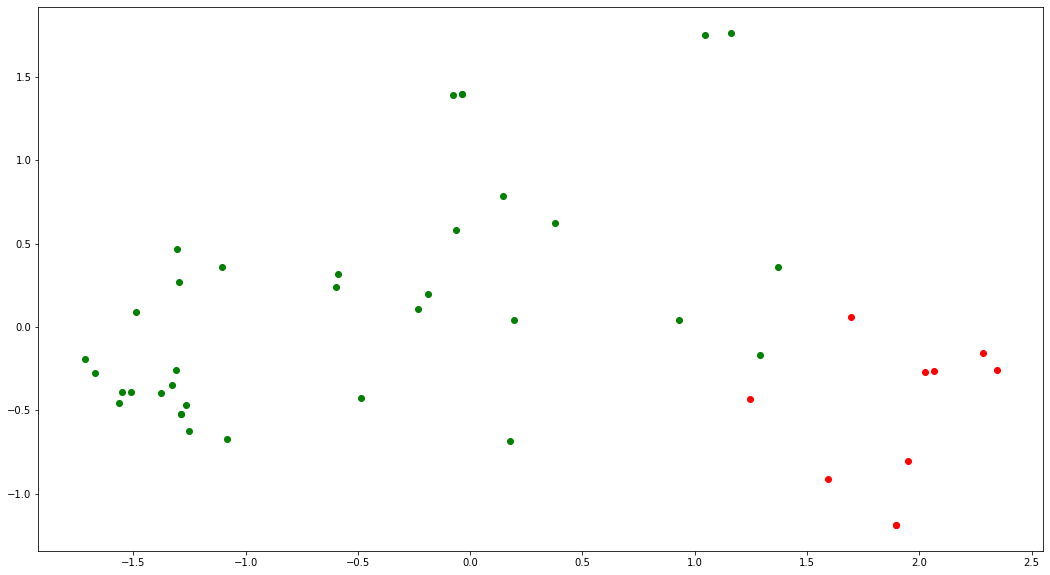

2 eng_at


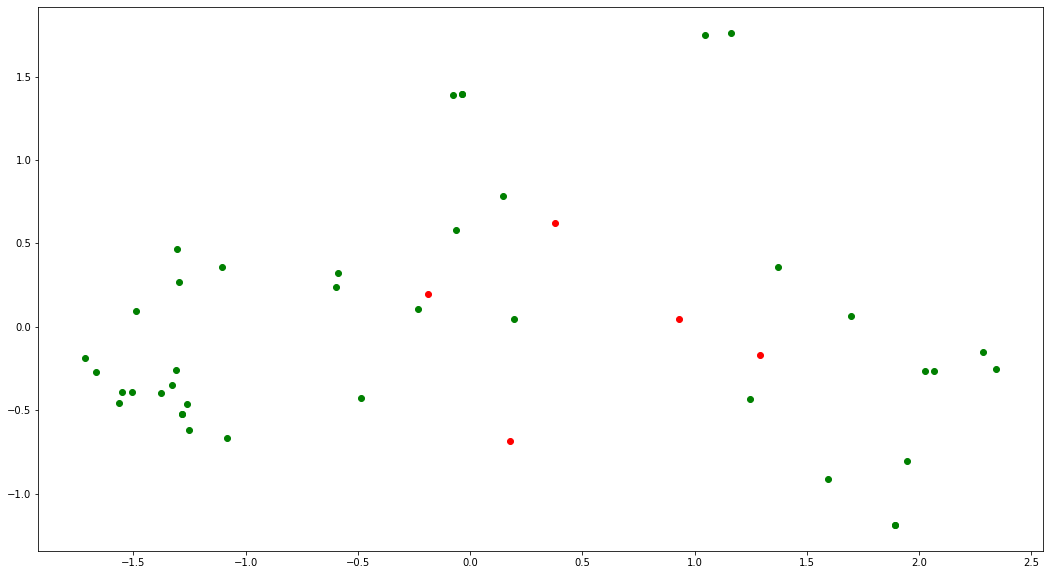

3 eng_by


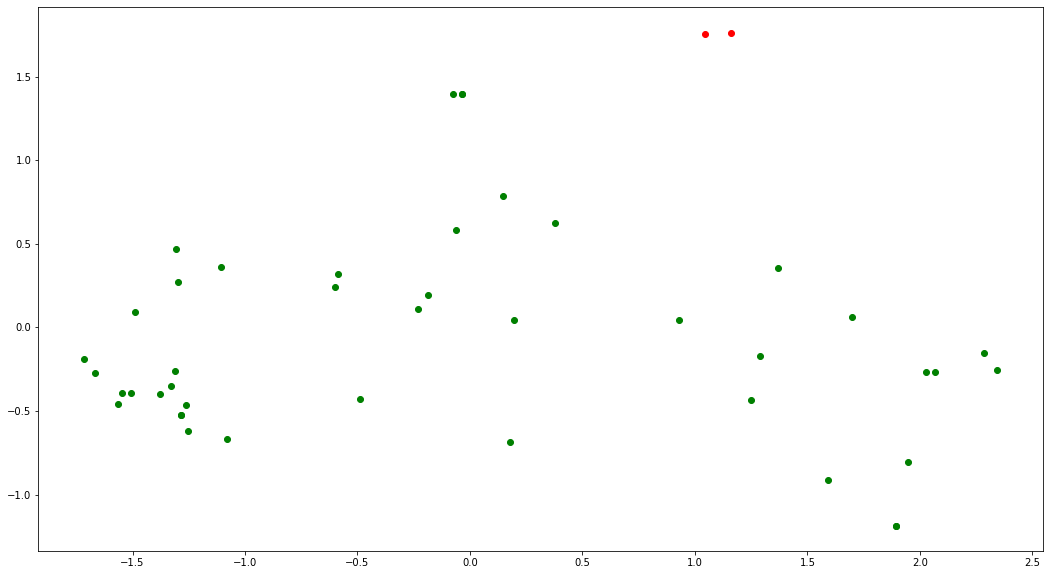

4 cym_yn


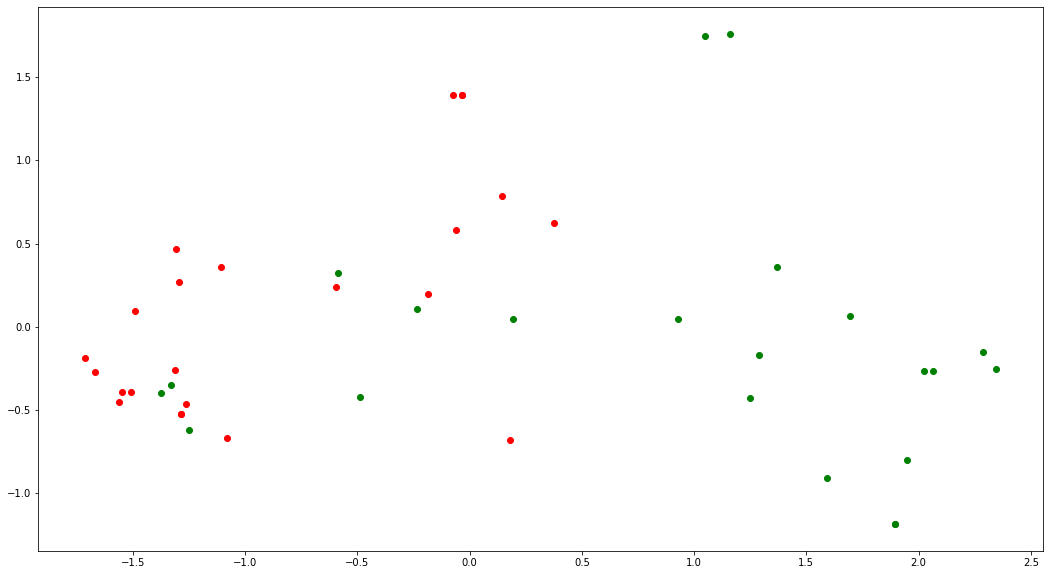

5 cym_ar


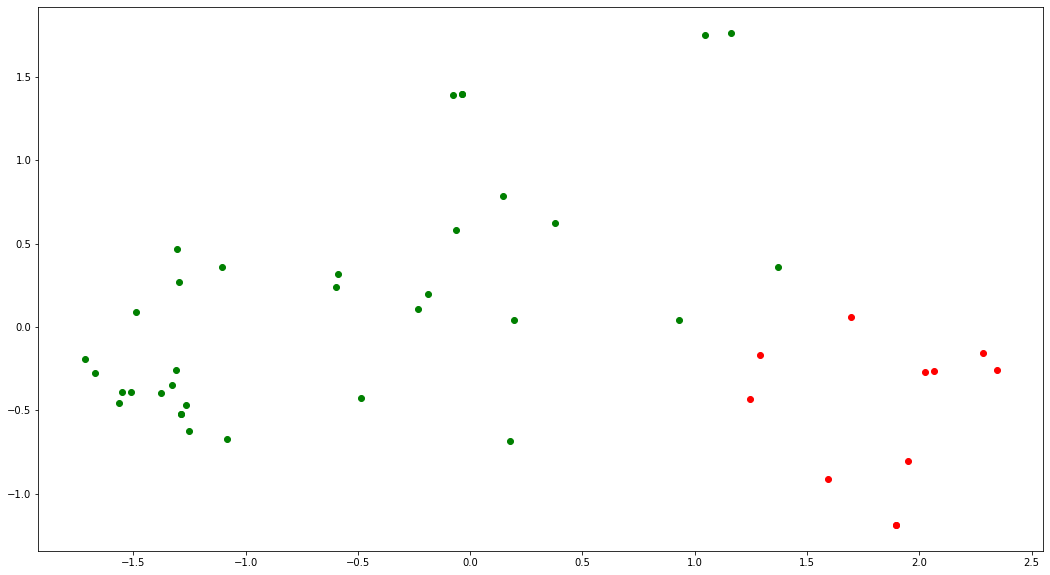

6 cym_zero


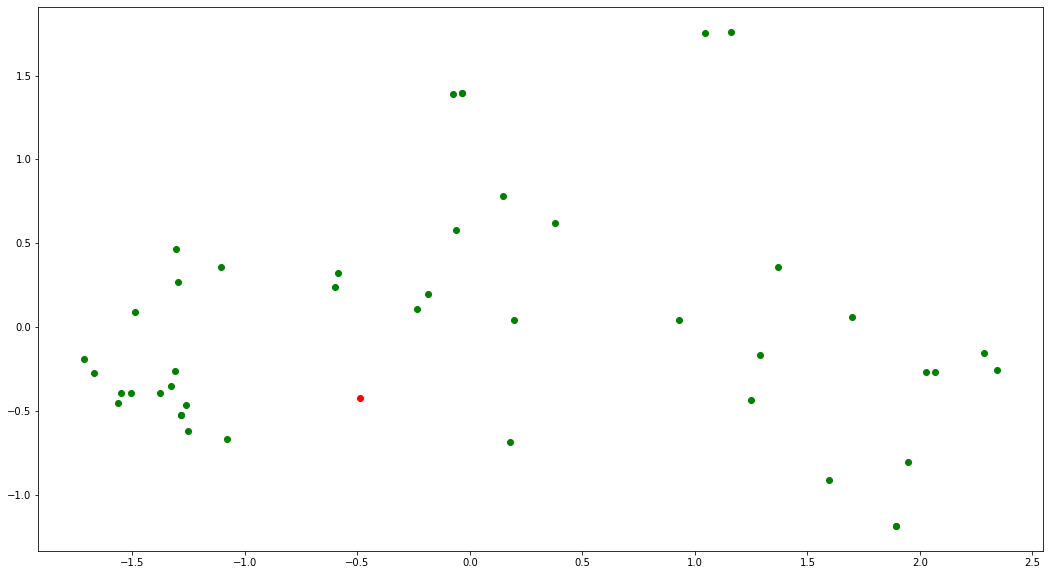

7 cym_mewn


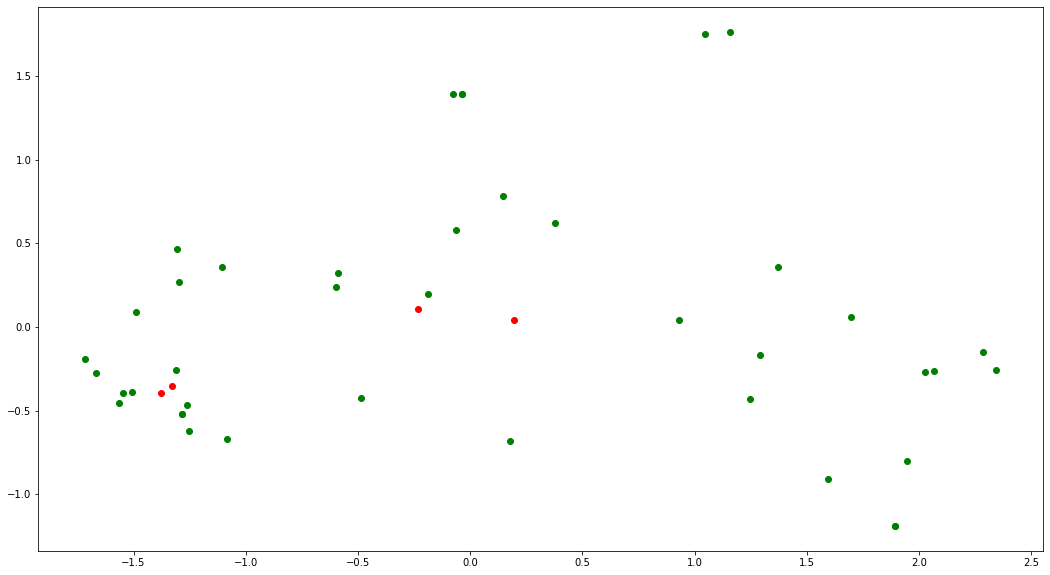

8 cym_wrth


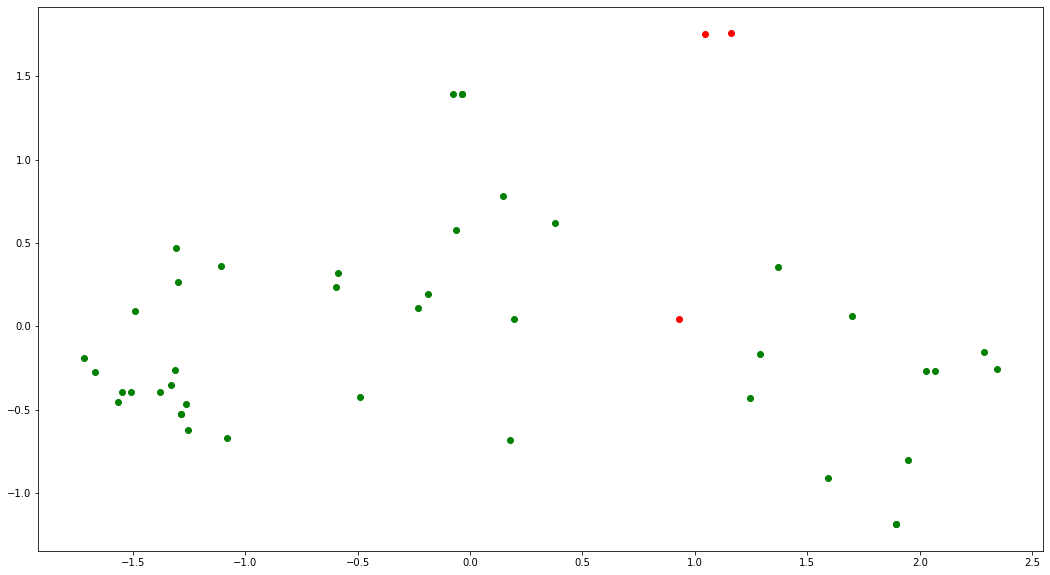

9 deu_in


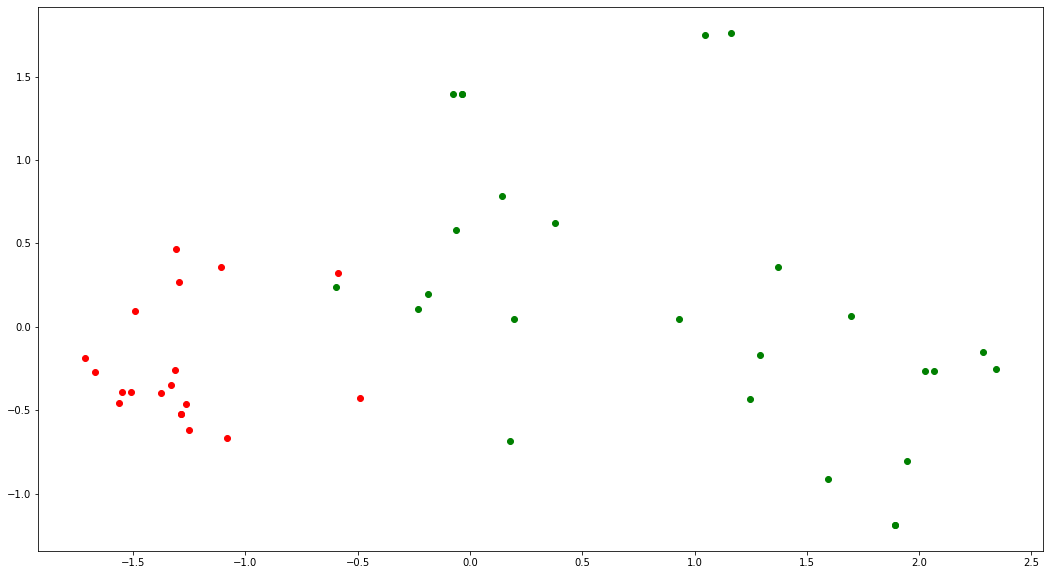

10 deu_auf


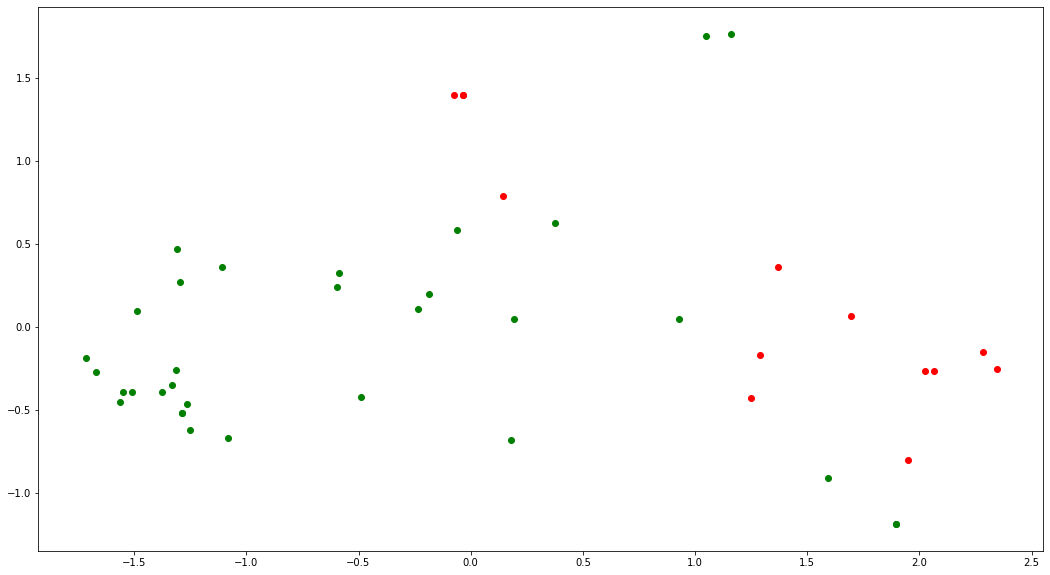

11 deu_zur


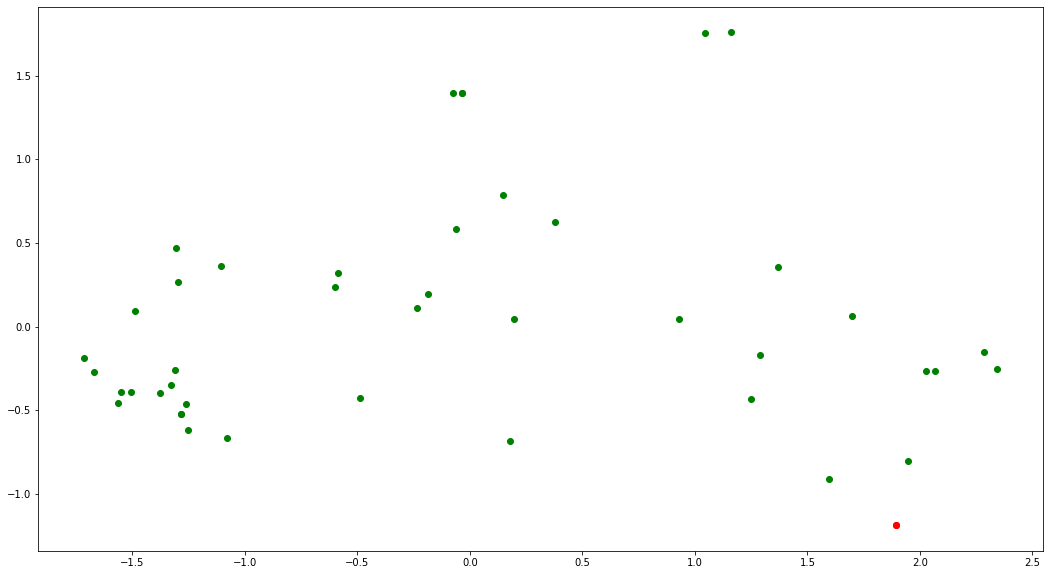

12 deu_vor


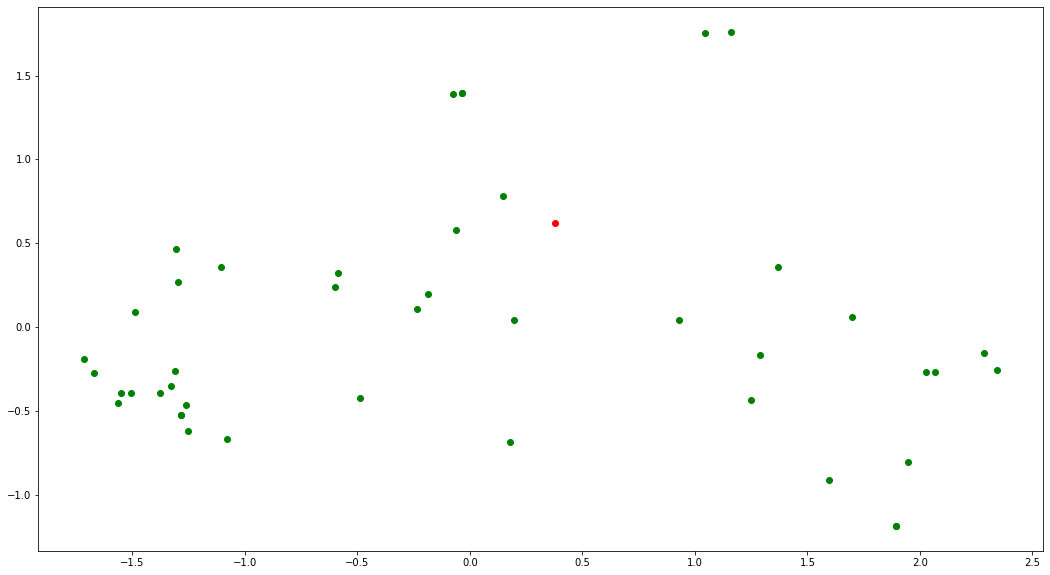

13 deu_an


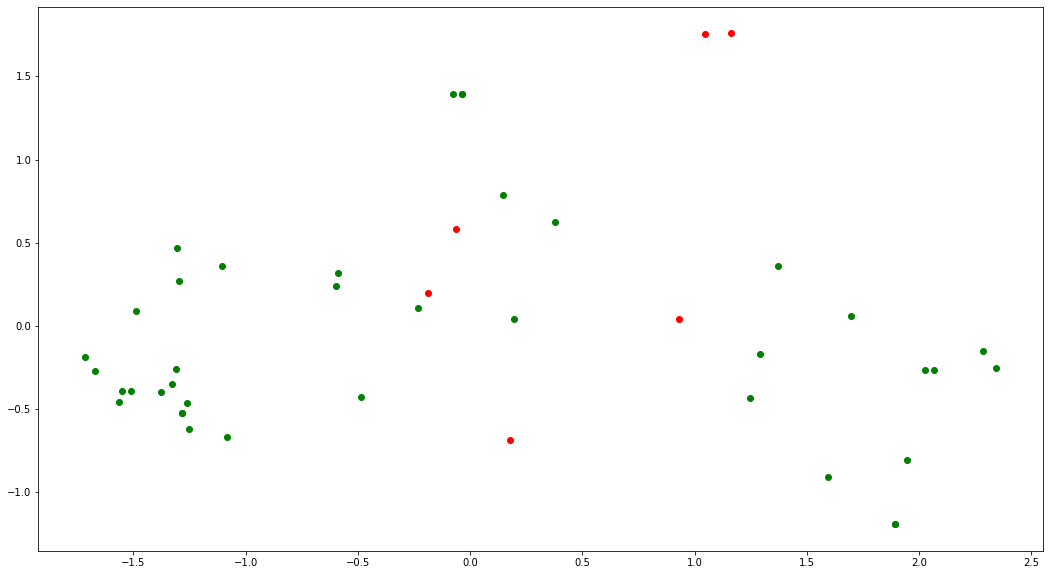

14 fin_-ssa


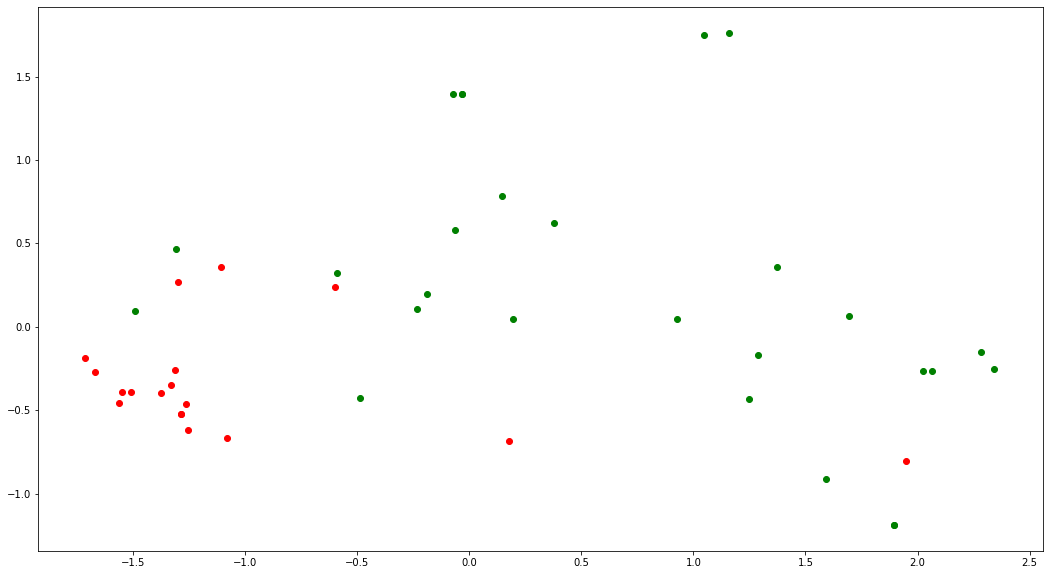

15 fin_-lla


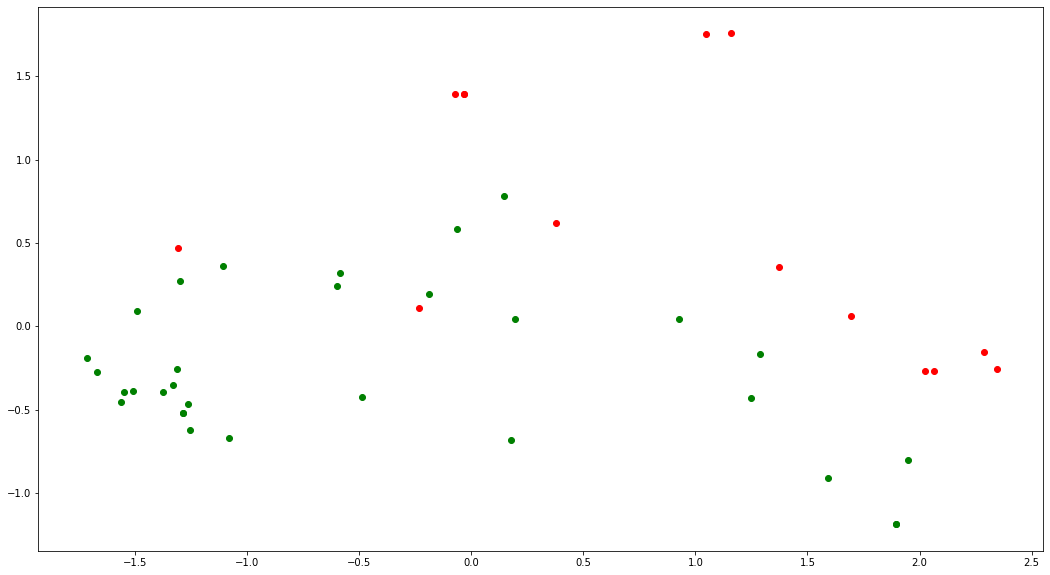

16 fin_-lle


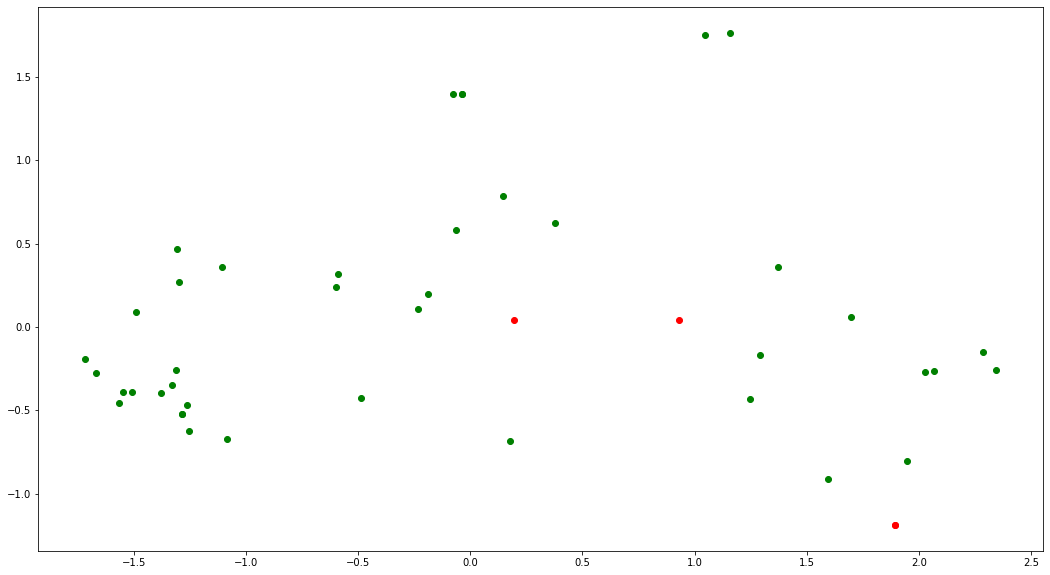

17 fin_zero


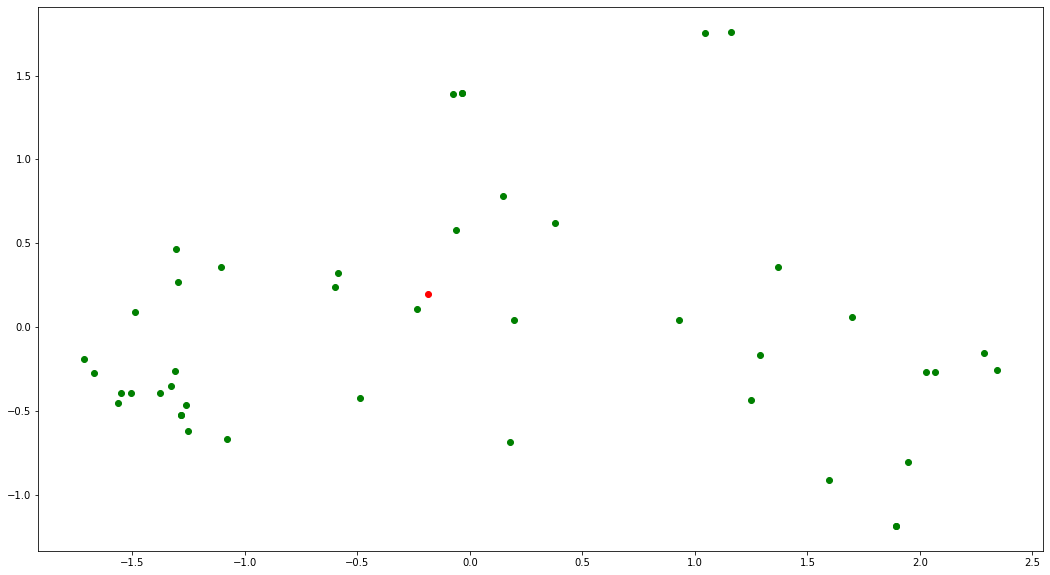

18 hat_nan


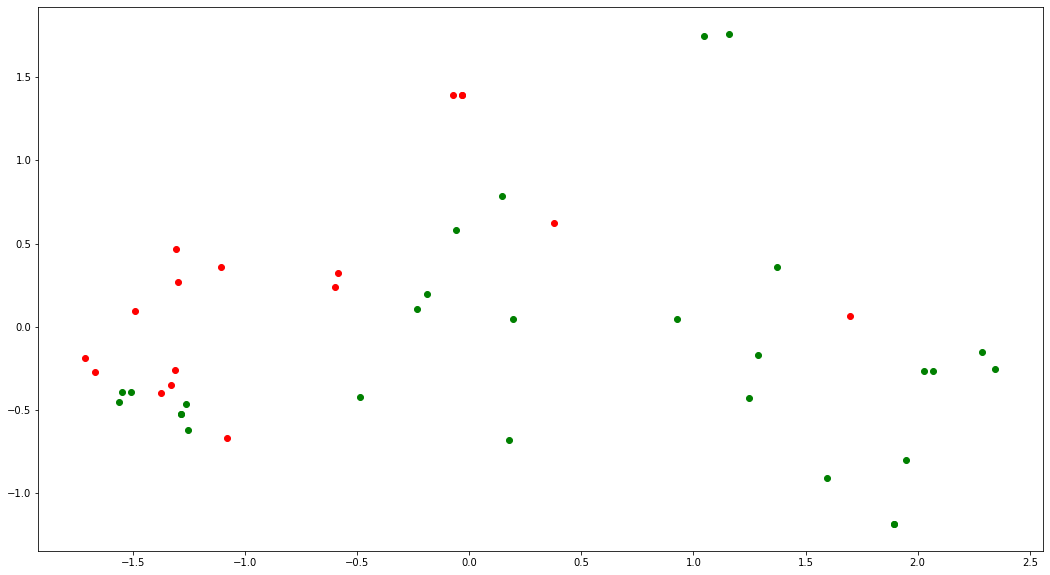

19 hat_sou


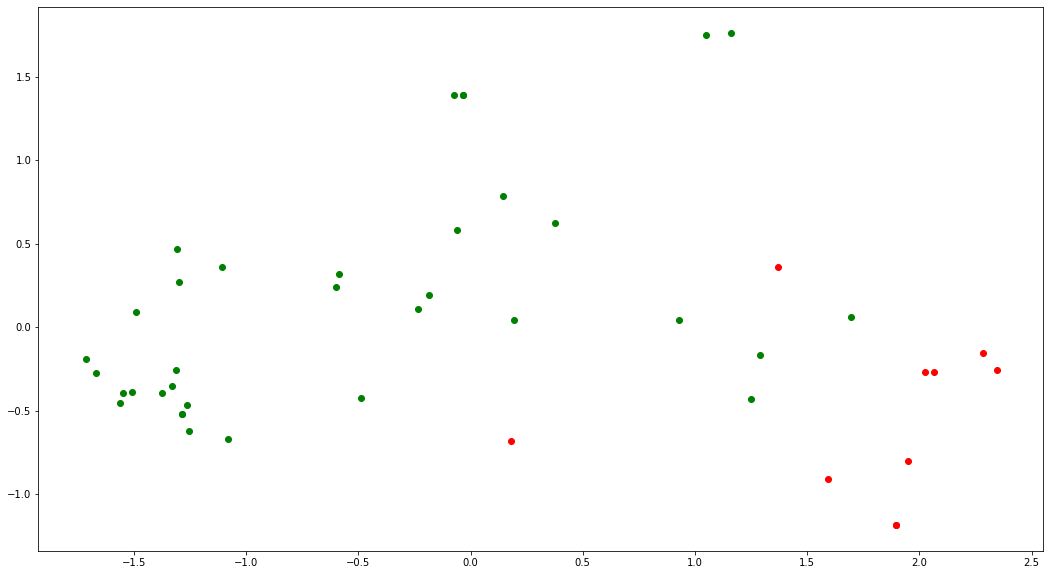

20 hat_zero


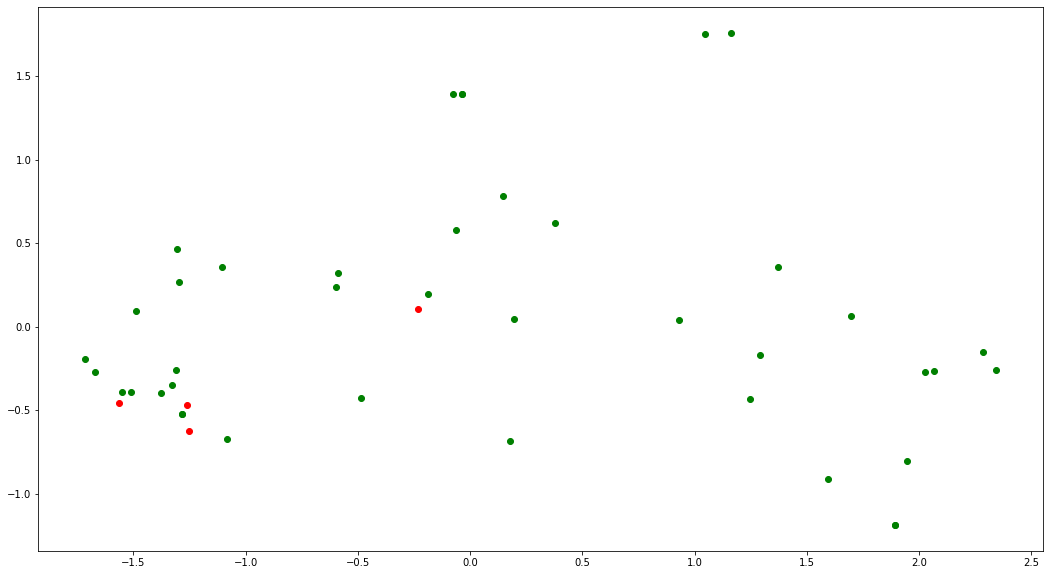

21 hat_bò_la


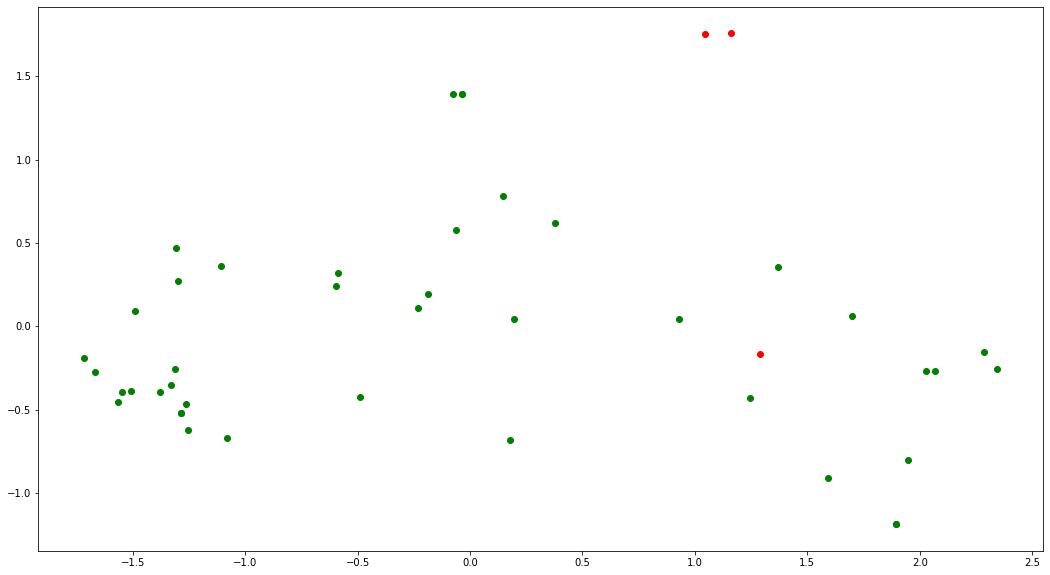

22 hau_cikin


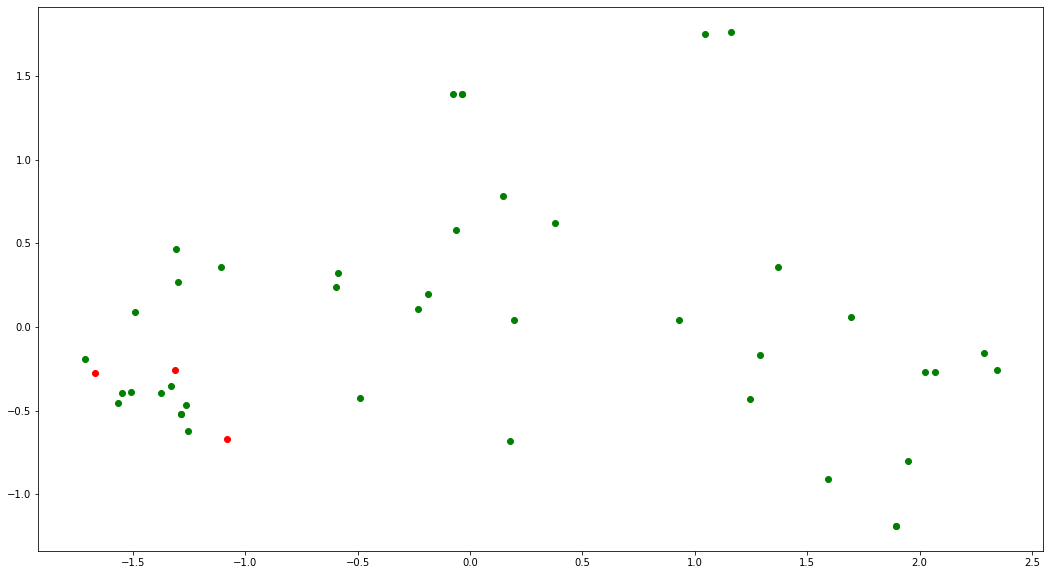

23 hau_a


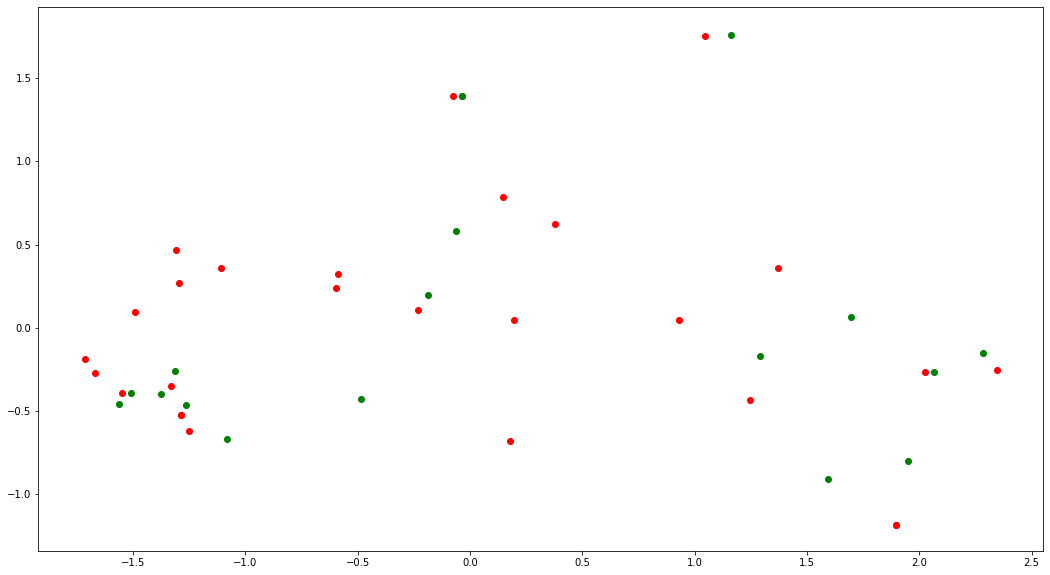

24 hau_kan


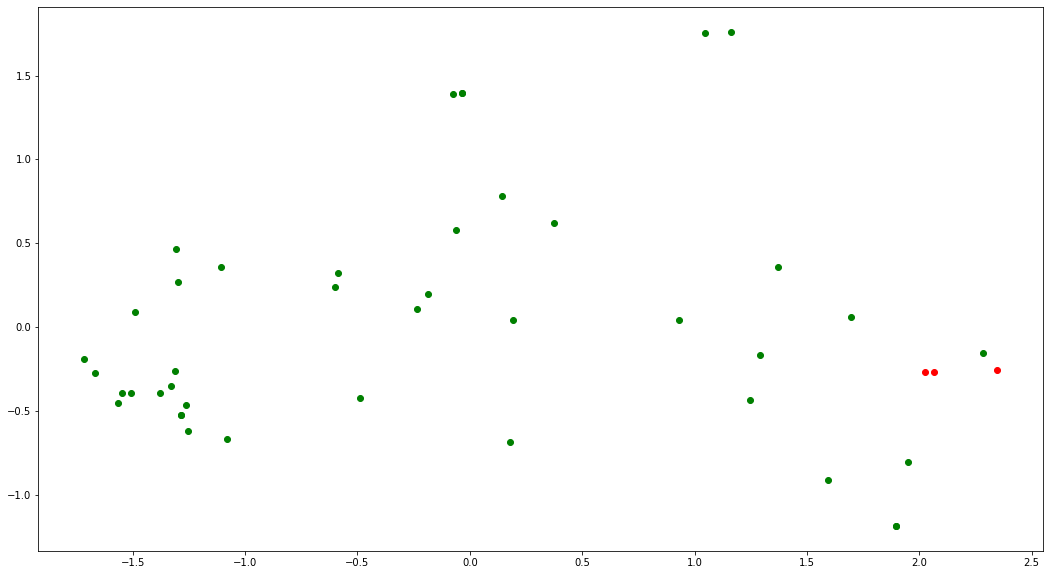

25 hau_ciki


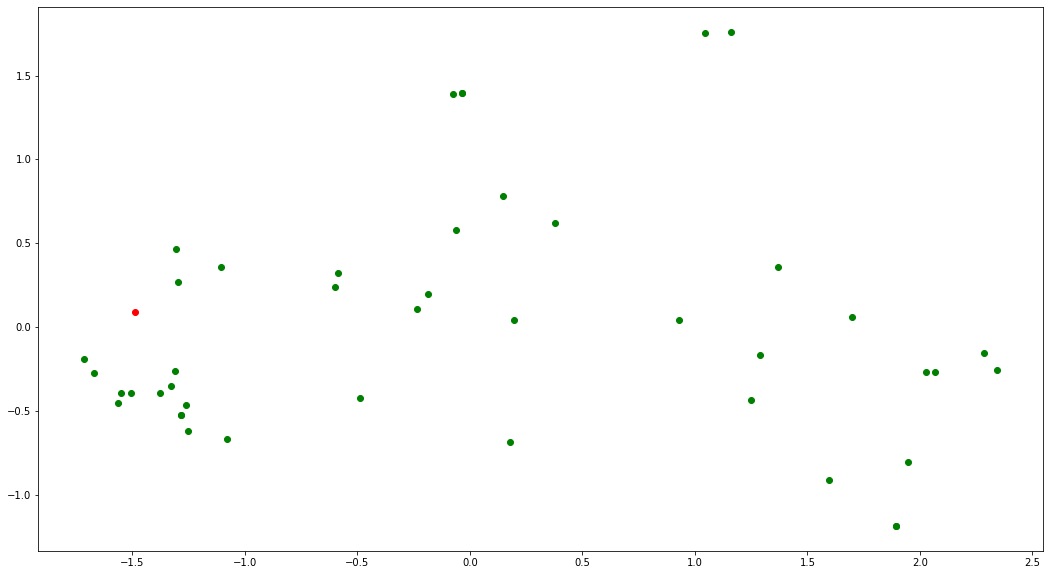

26 hau_zero


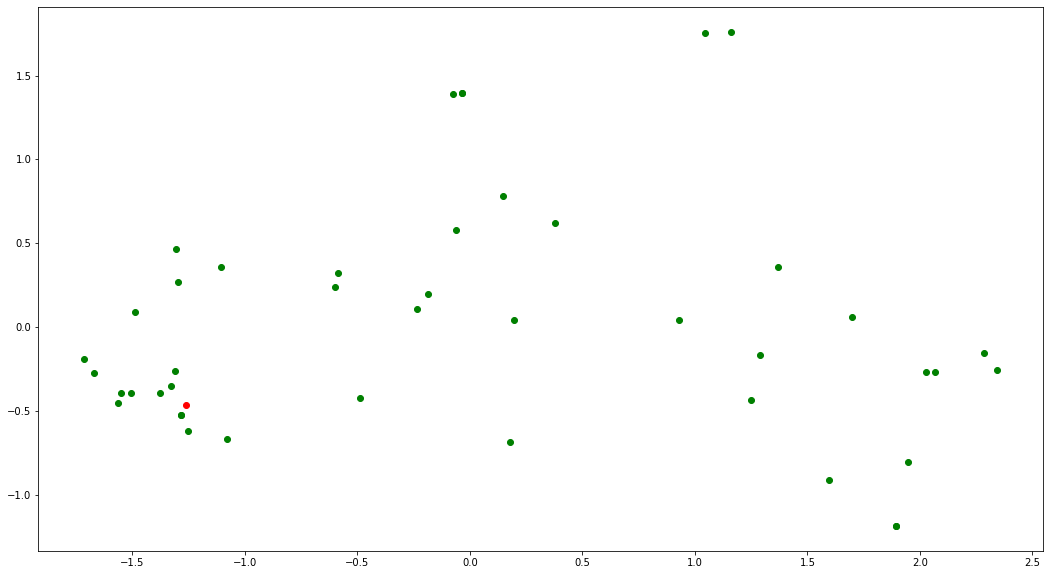

27 hin_mẽ


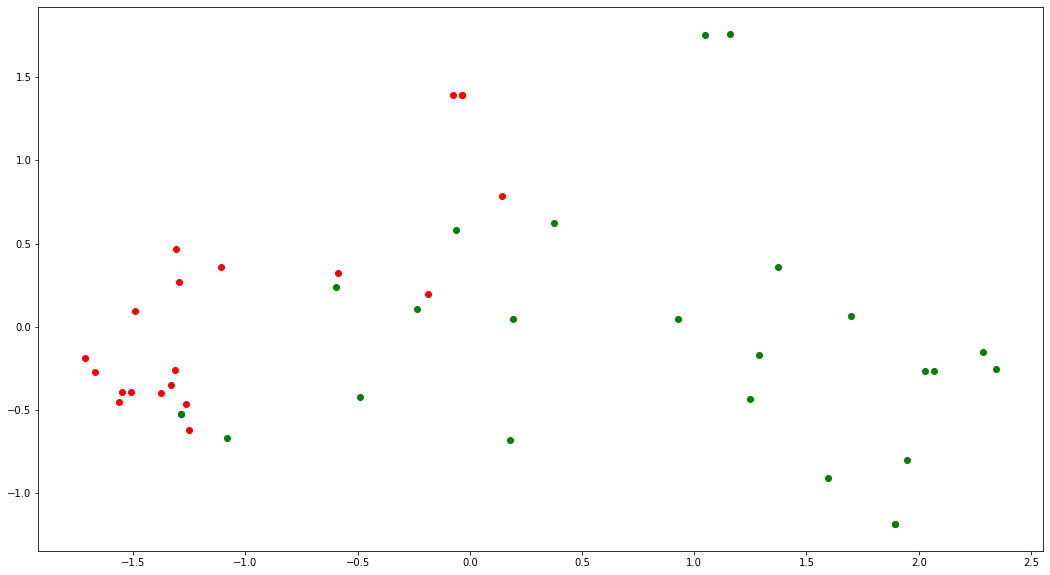

28 hin_par


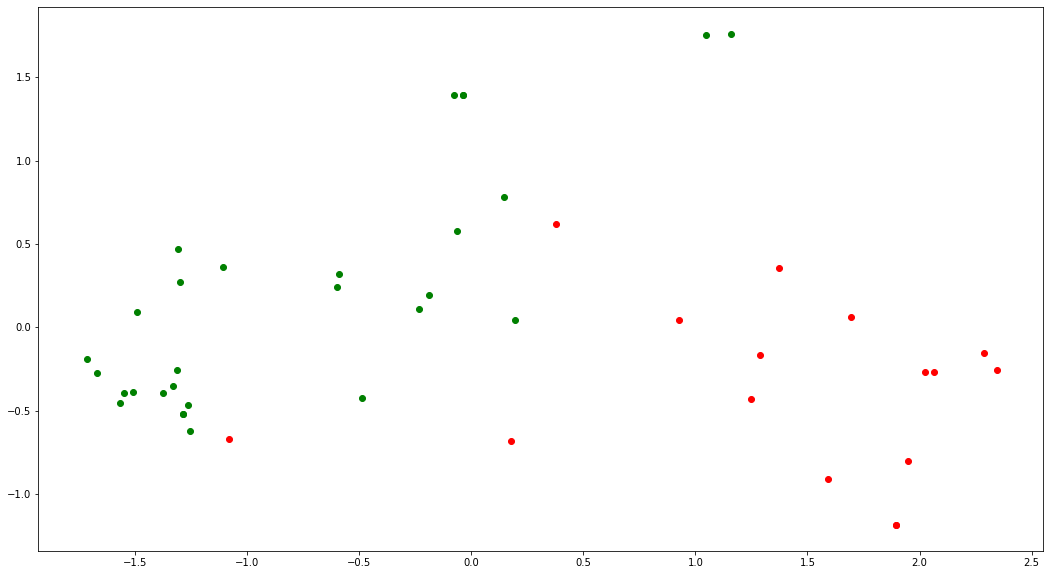

29 hin_zero


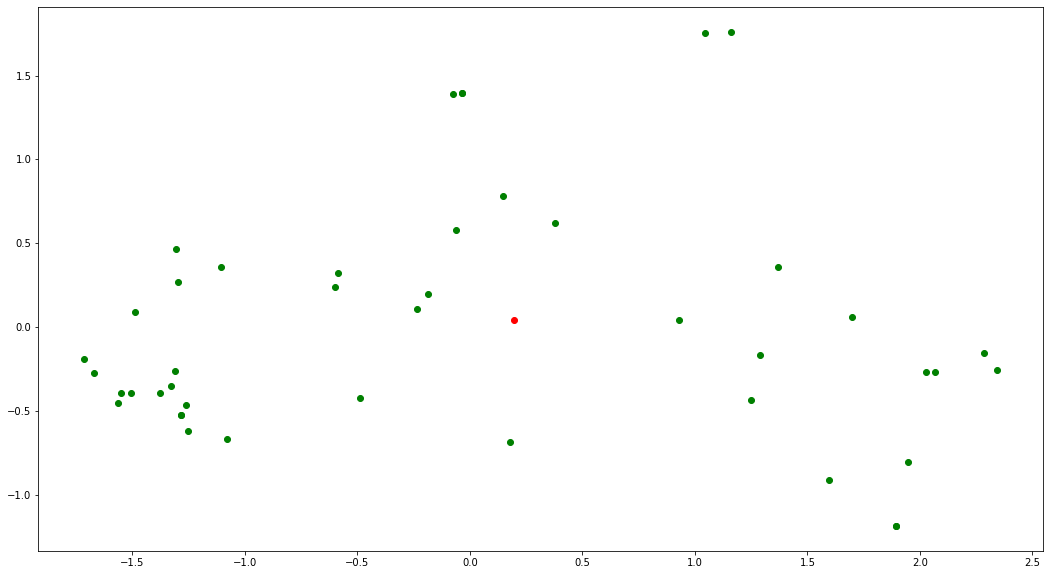

30 hin_ke


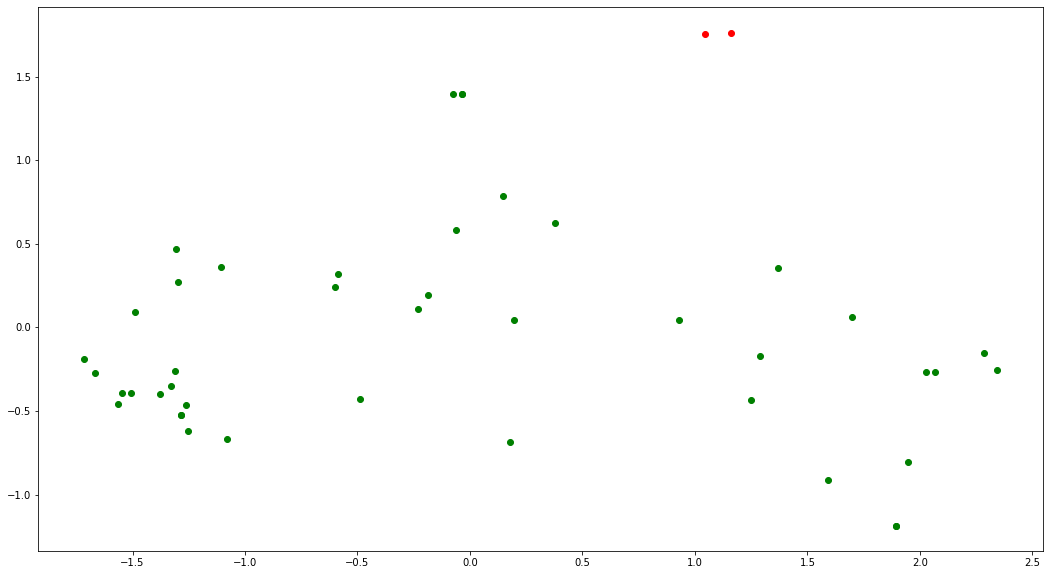

31 hin_pas


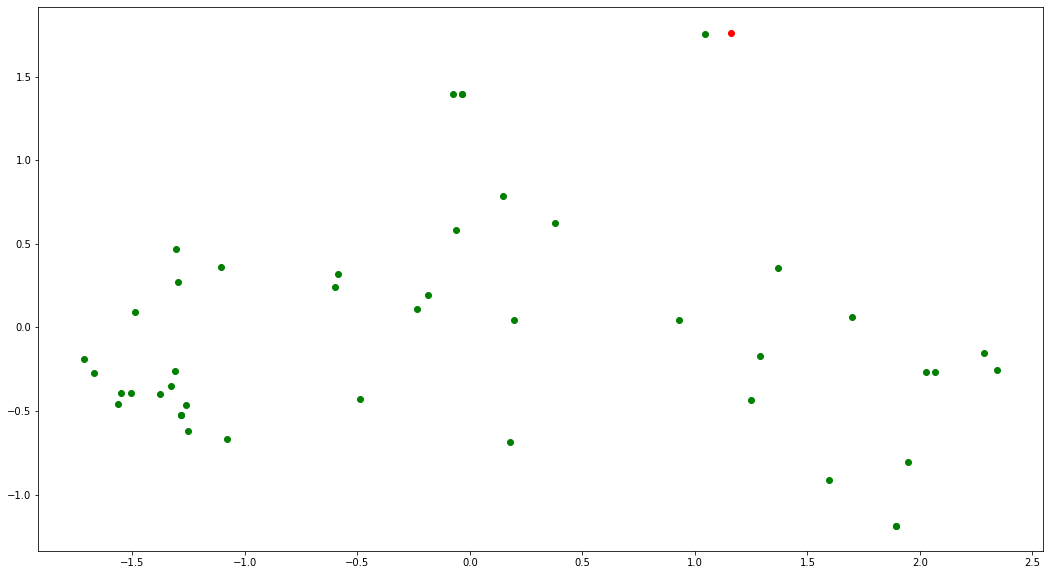

32 hin_kinare


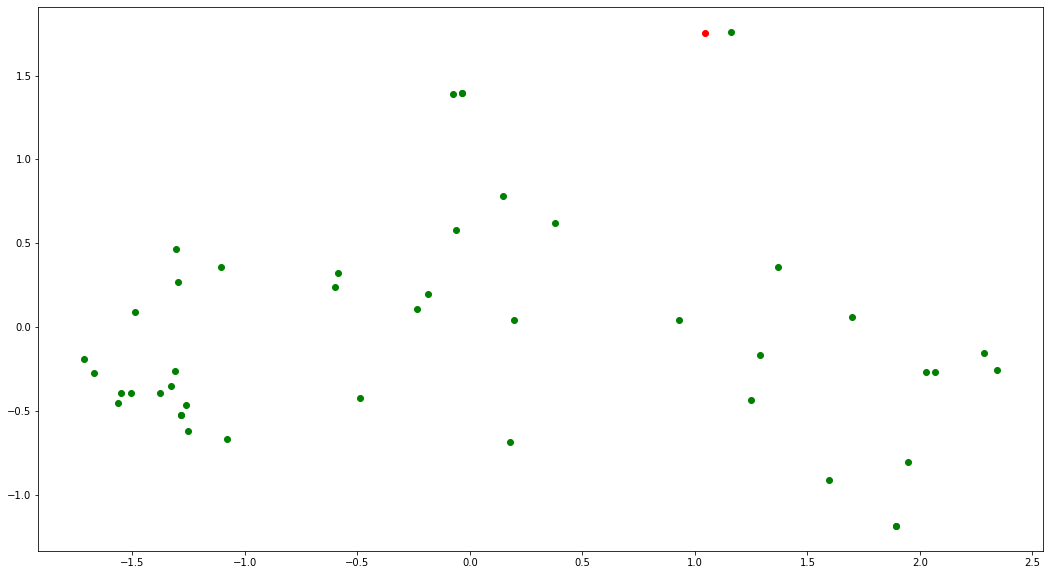

33 jav_ing


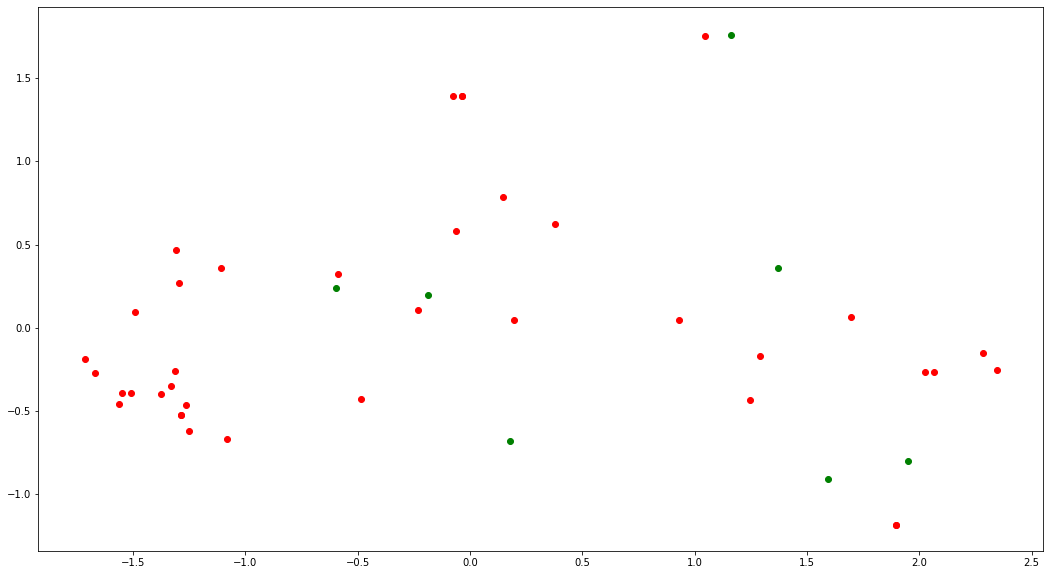

34 jav_sacedhaké


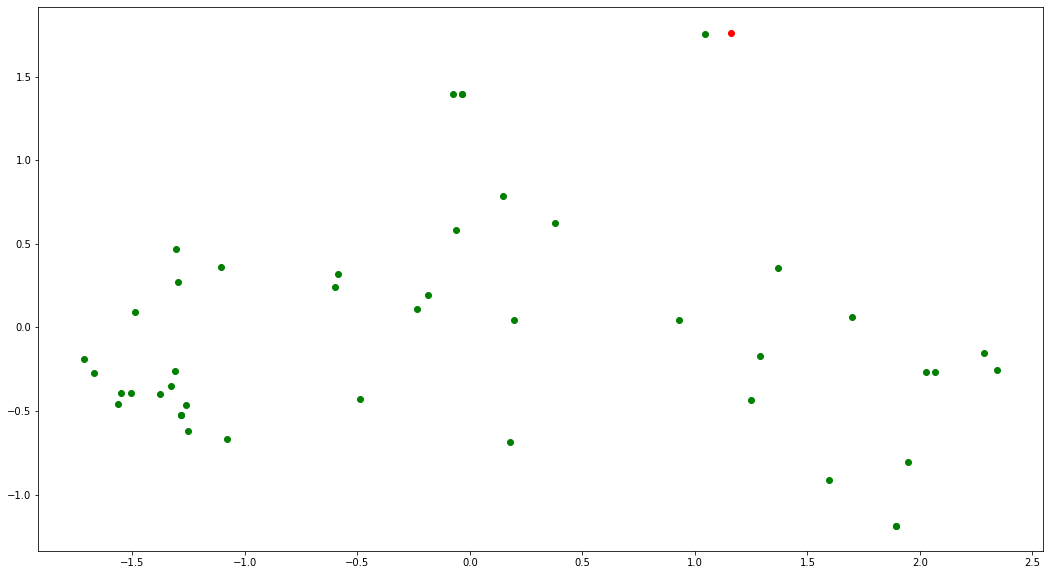

35 jav_sacedhaking


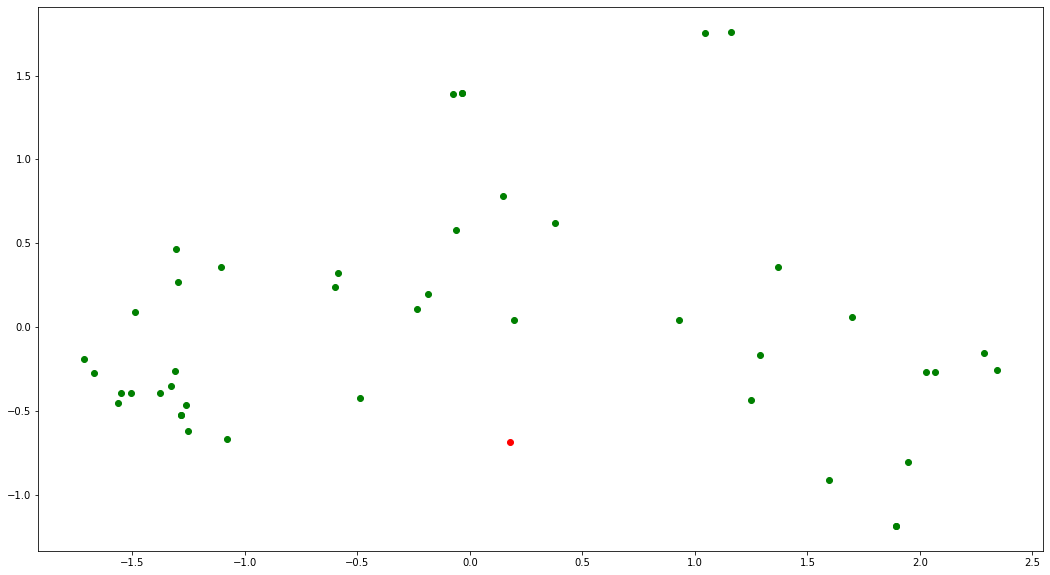

36 jav_pinggir


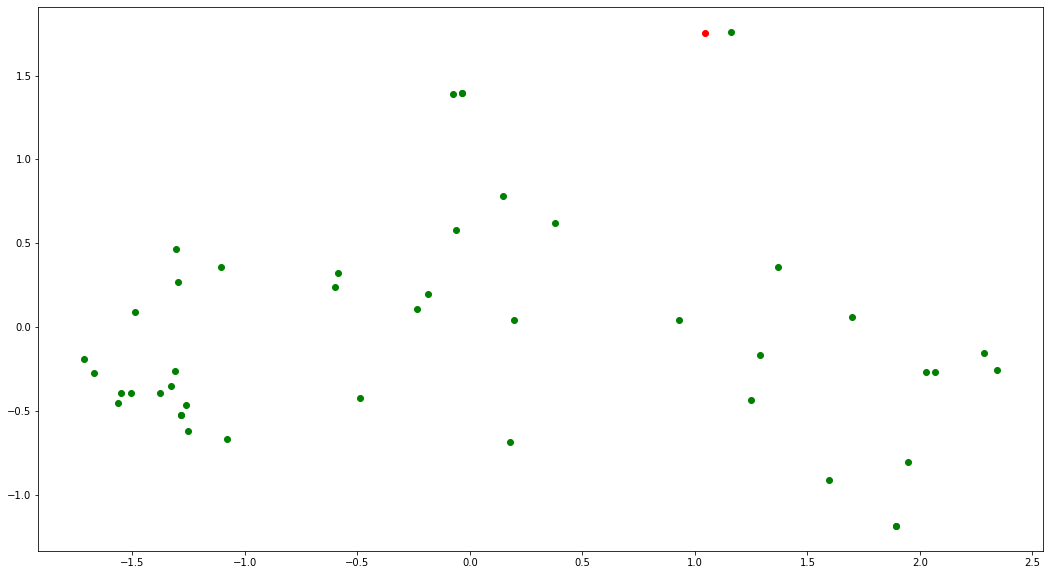

37 jav_sajroning


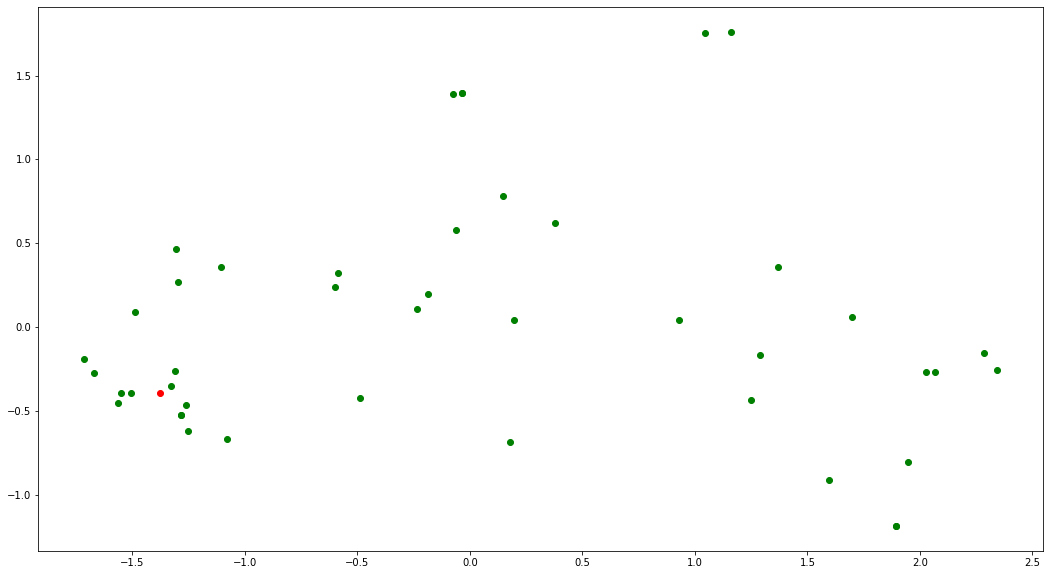

38 jav_sakiwa


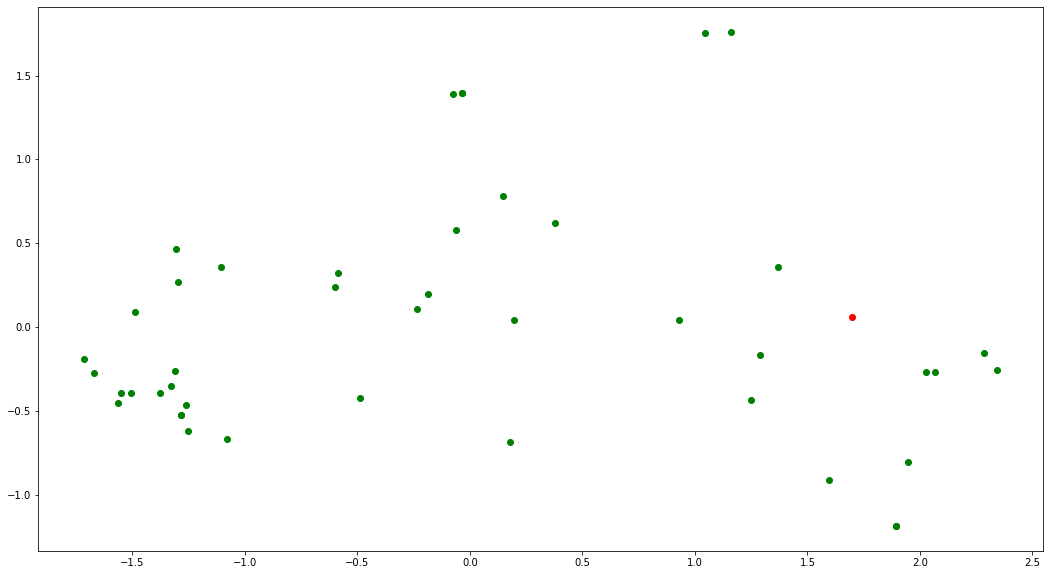

39 jav_tengené


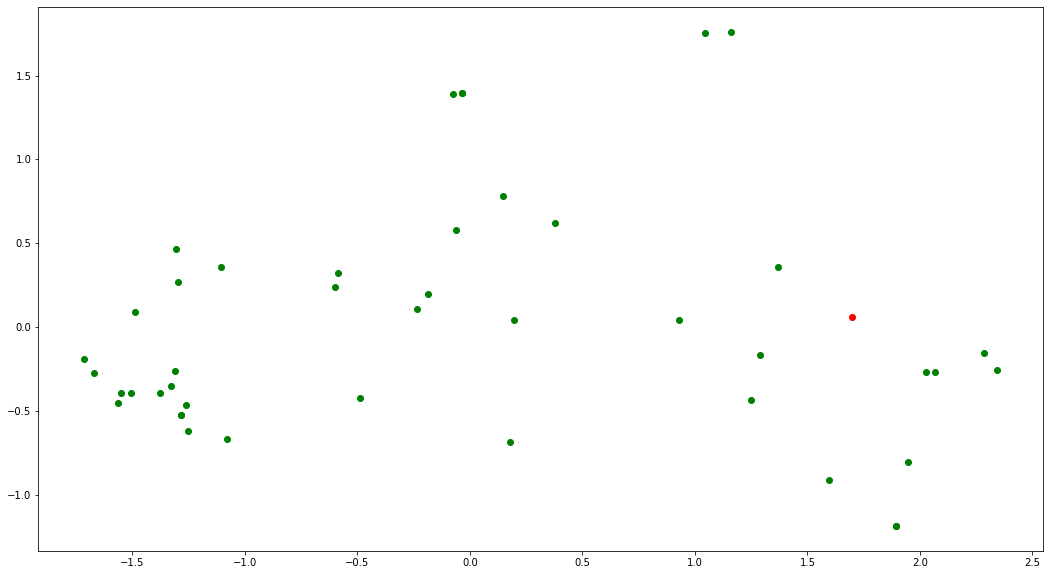

40 pol_w


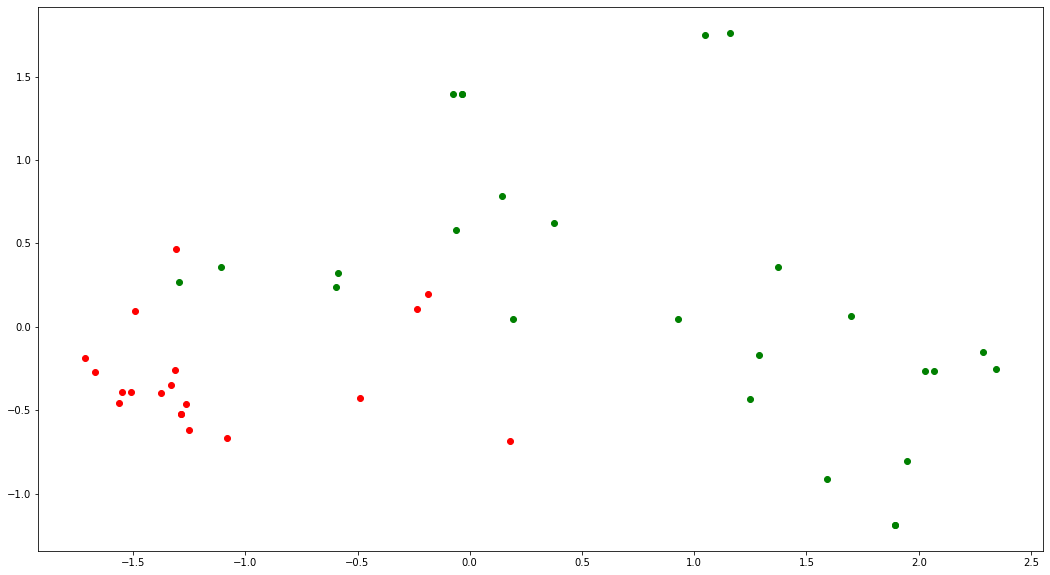

41 pol_na


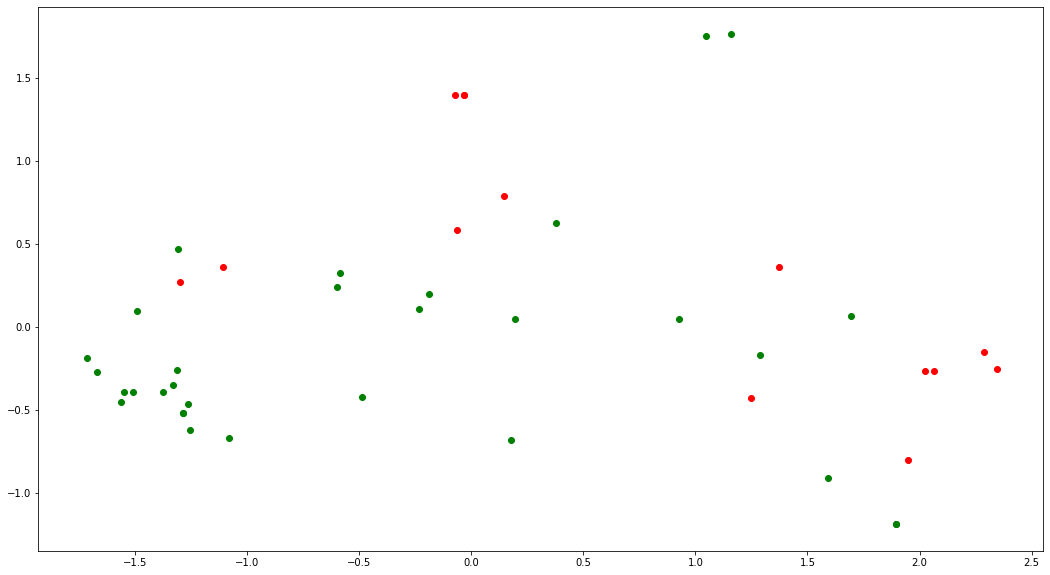

42 pol_z


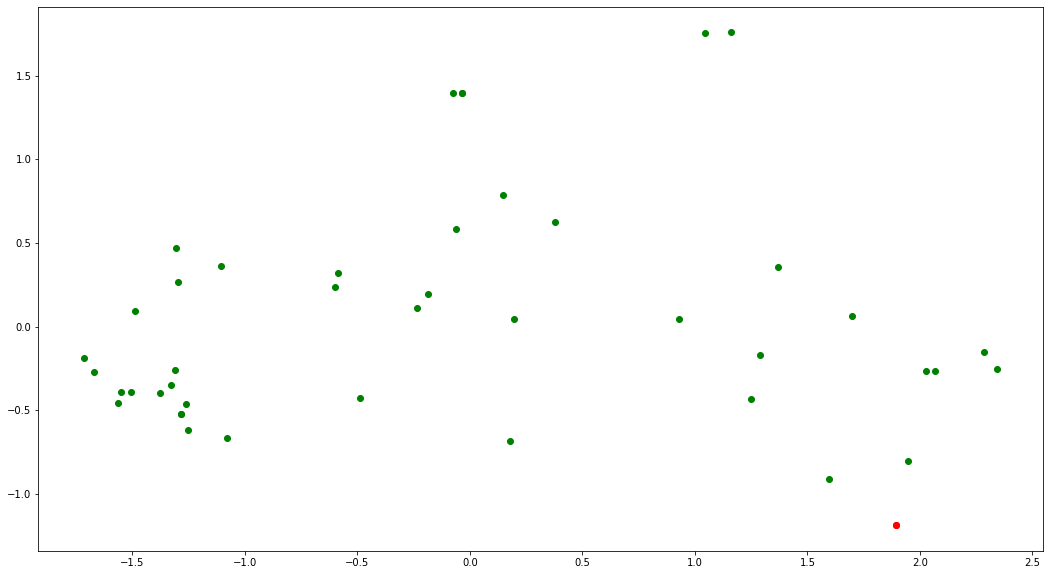

43 pol_u


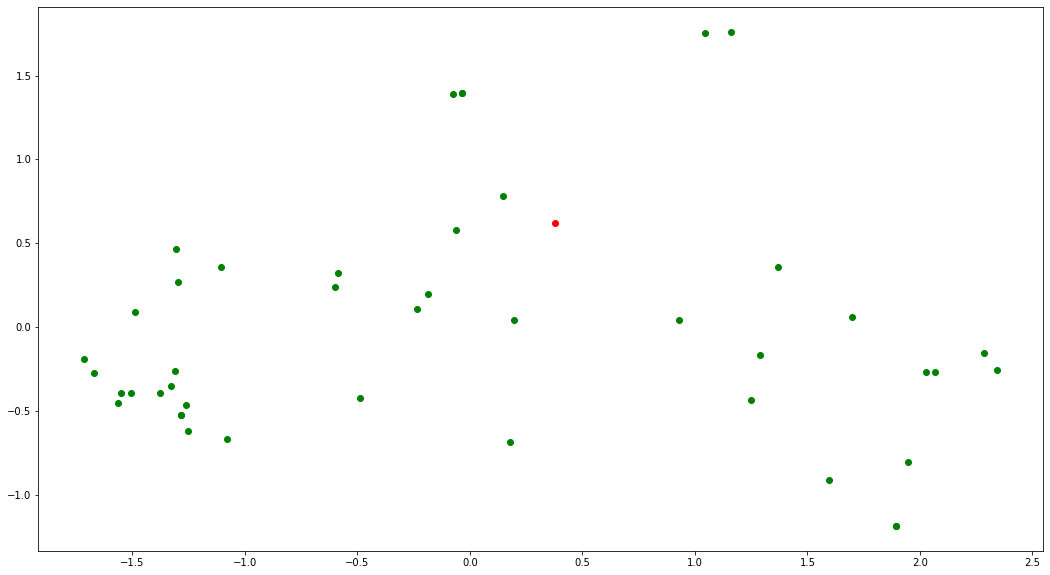

44 pol_przy


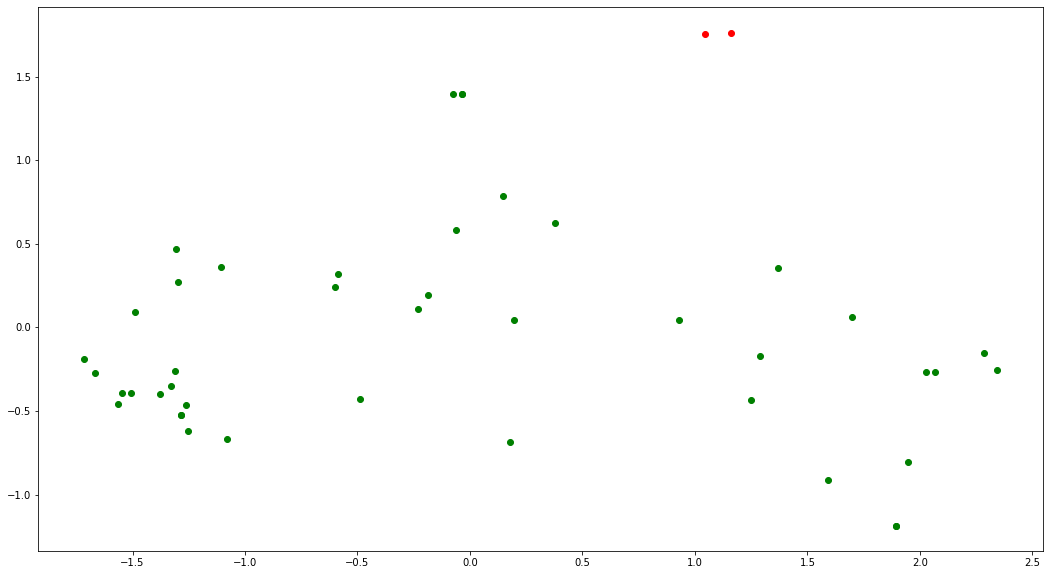

45 tur_-inda


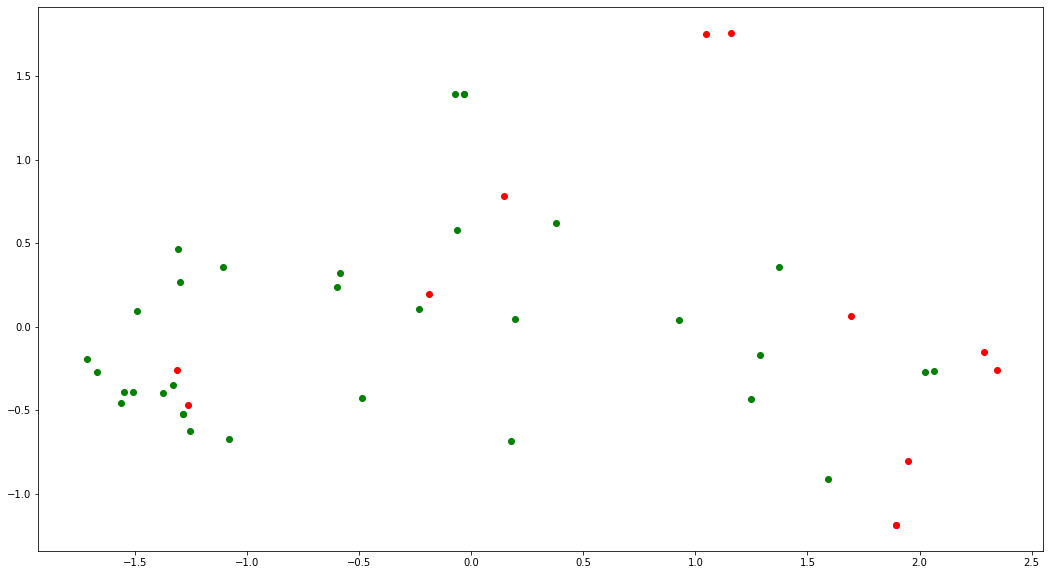

46 tur_-da


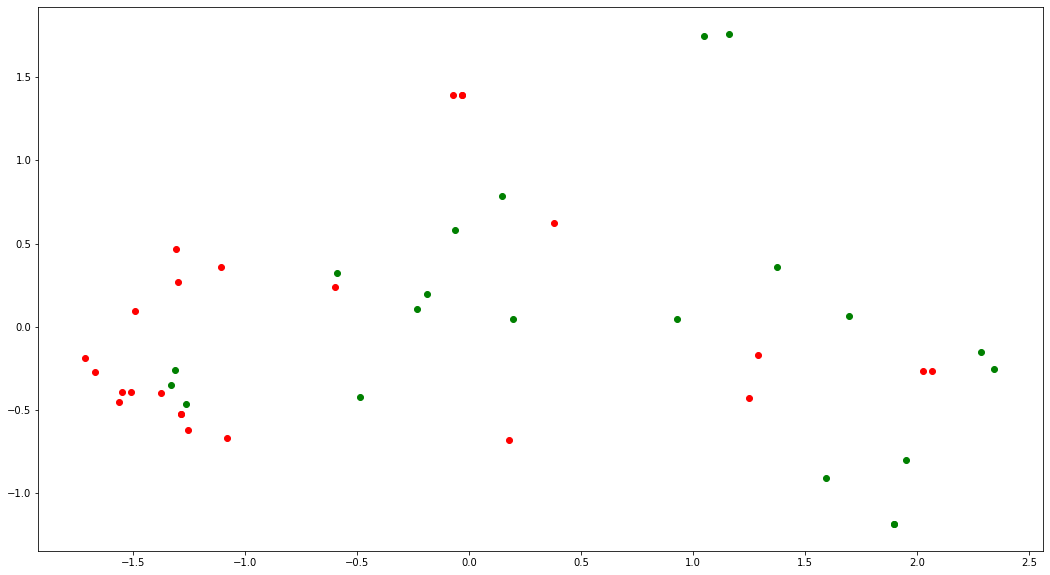

47 yor_ninu


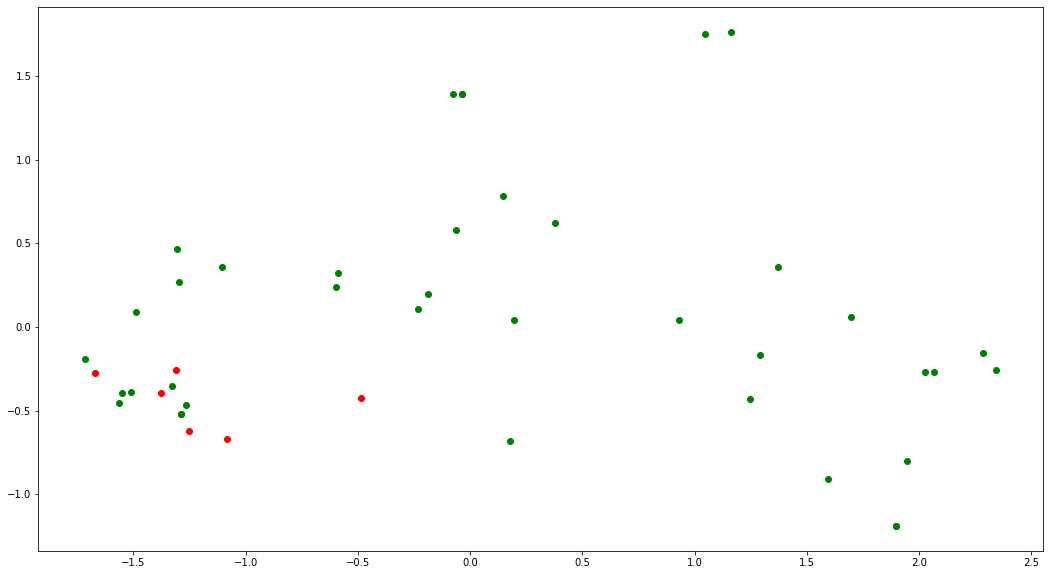

48 yor_li


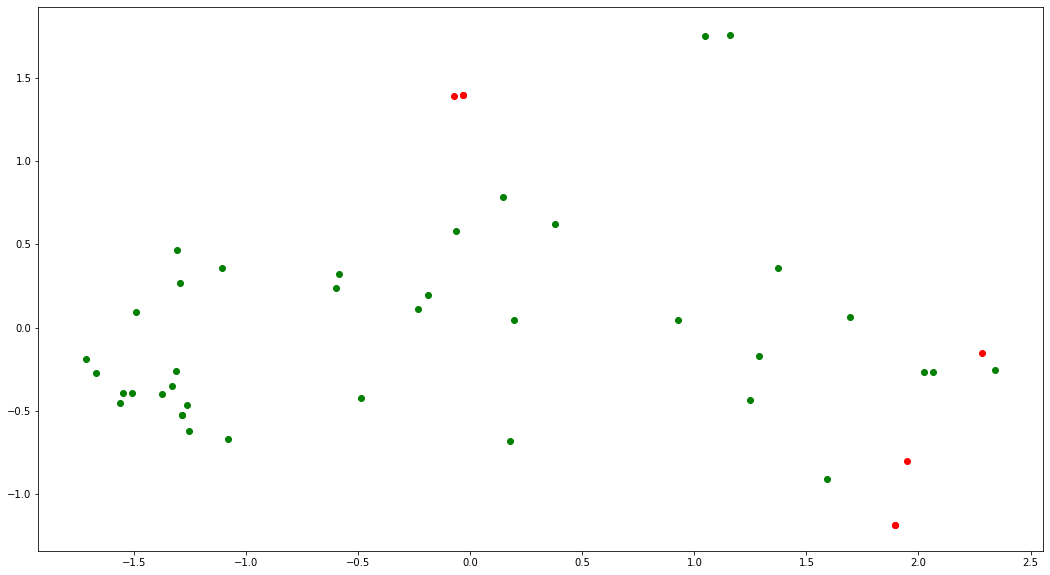

49 yor_ni


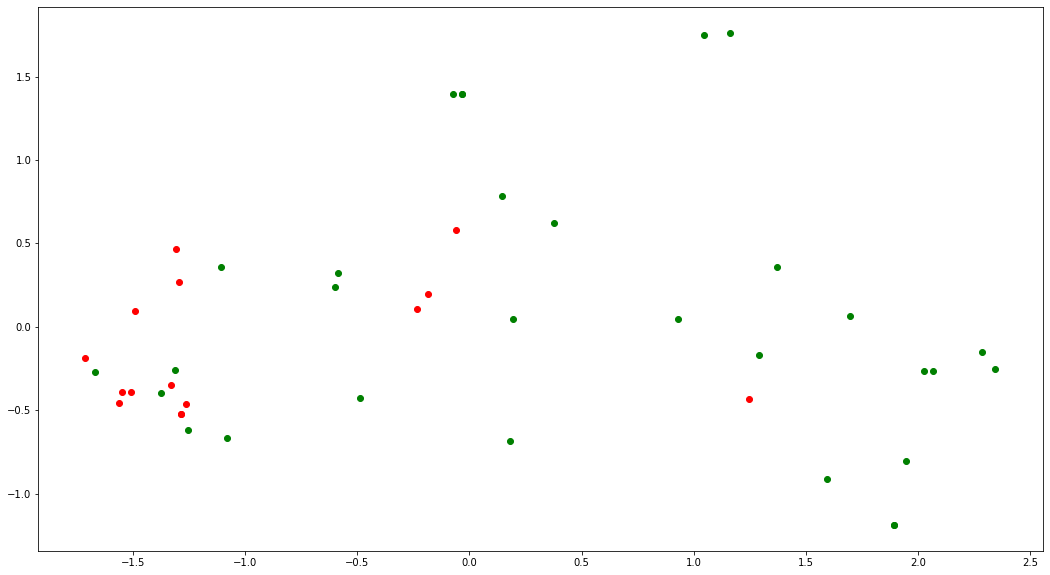

50 yor_lori


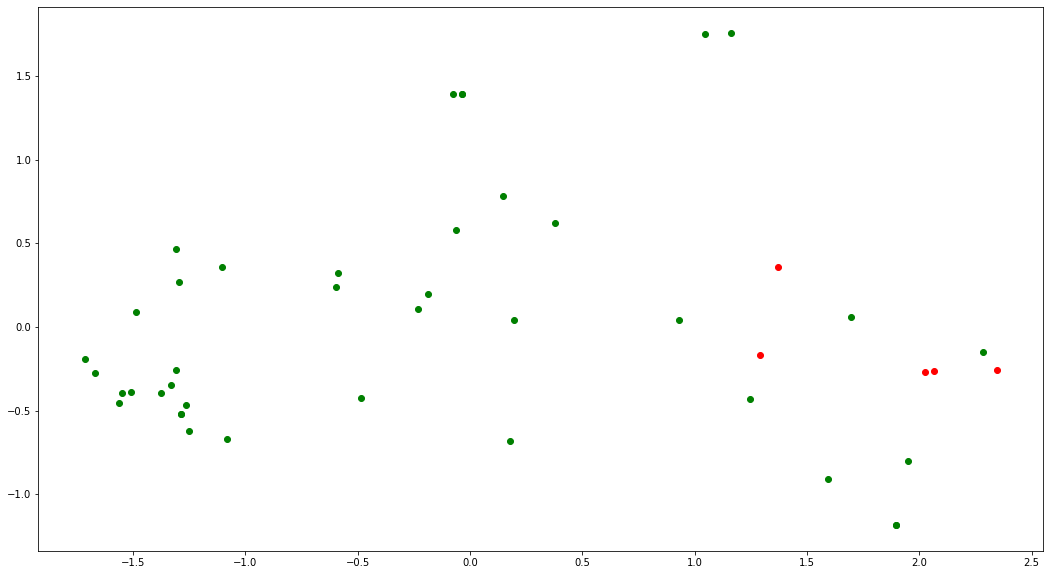

51 yor_lẹhin


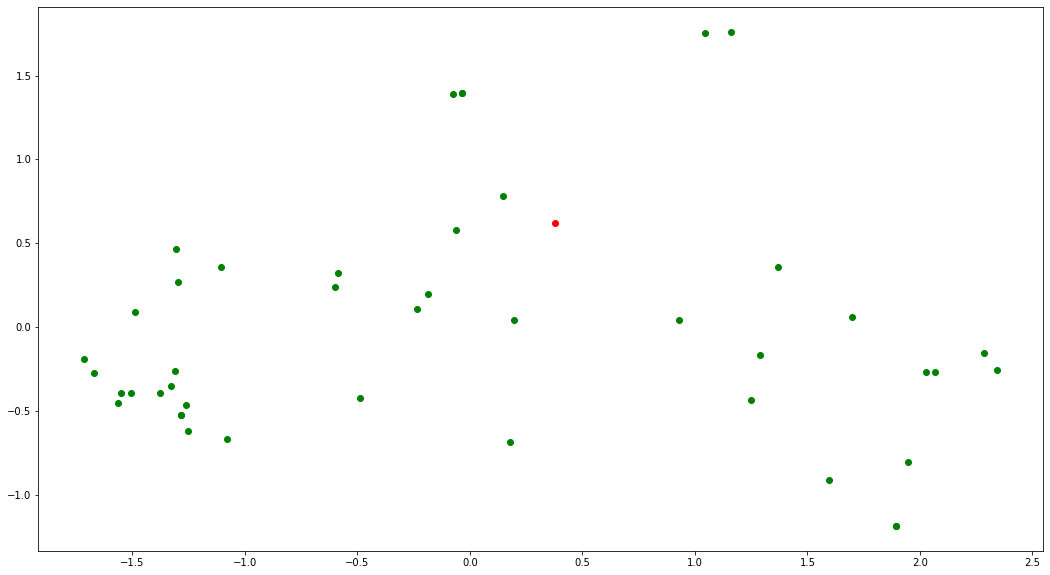

52 yor_sinu


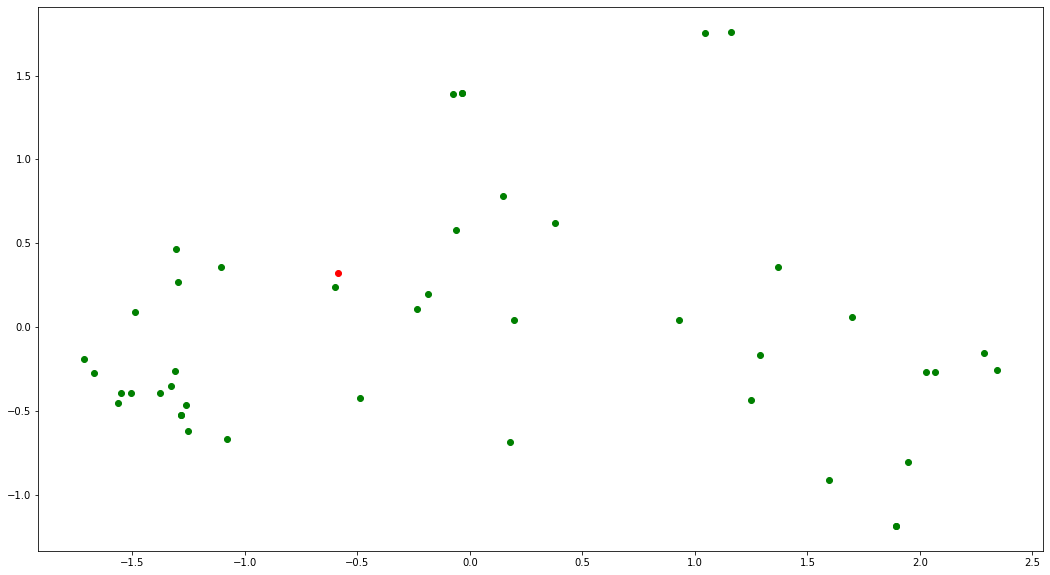

53 yor_leti


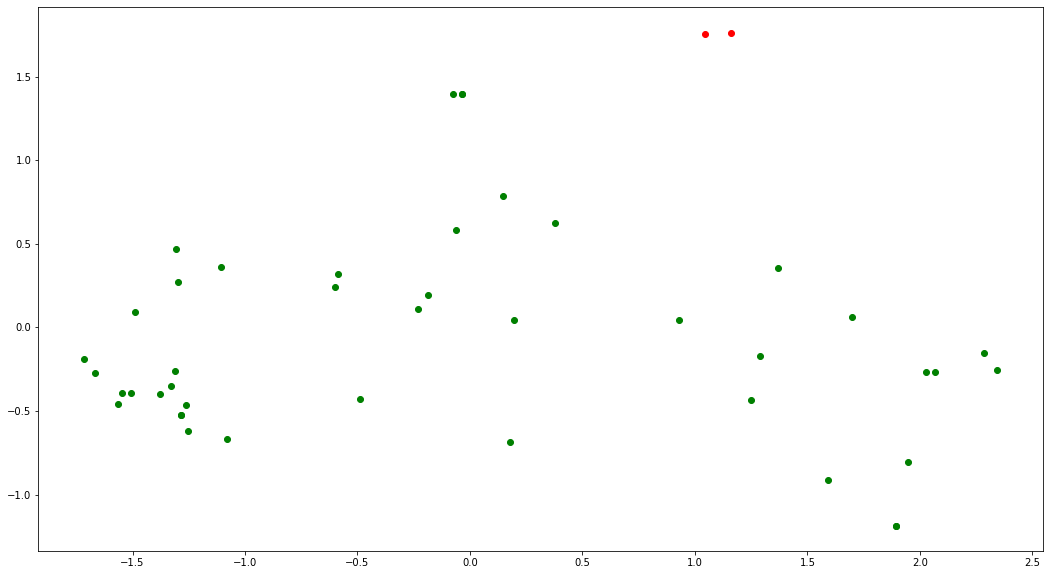

In [6]:
from matplotlib import pyplot as plt
dimension_x = 0
dimension_y = 2
plt.rcParams["figure.figsize"] = (18,10)
plt.scatter(x=coordinates[:,dimension_x],y=coordinates[:,dimension_y])
for i,row in enumerate(dense_coding_table[1:]):
    plt.text(x=coordinates[i,dimension_x],y=coordinates[i,dimension_y],s=dense_coding_table[i+1][0])
    print(coordinates[i,dimension_x],coordinates[i,dimension_y],dense_coding_table[i+1][0])
plt.show()
for i,term in enumerate(header):
    print(i,term)
    present = [j for j,row in enumerate(sparse_coding_table) if row[i] == 1]
    absent  = [j for j,row in enumerate(sparse_coding_table) if row[i] == 0]
    plt.scatter(x=coordinates[present,dimension_x], y=coordinates[present,dimension_y], c = 'r')
    plt.scatter(x=coordinates[absent,dimension_x], y=coordinates[absent,dimension_y], c = 'g')
    plt.show()
    plt.close()